# Nicer FairGame Combined: Strategy & Behavioral Analysis

**Combined analysis pipeline** integrating:
1. **LSTM Strategy Detection** (from FairGame/ClusteringResearch)
2. **Rule-Based Strategy Override** (AllC, AllD, TFT, WSLS)
3. **Behavioral Profile Analysis** (from nicer_than_humans - ICWSM'25)
4. **SFEM** (Strategy Frequency Estimation Method)
5. **Paper-Ready Visualizations**

### Data Format
- Actions: `C` (Cooperate) / `D` (Defect)
- Rounds: 30 per game
- Penalty scoring: CC=2, DD=8, DC=0(defector), CD=10(cooperator)
- Noise: intended vs final strategy (0%, 5%, 20%)
- Models: Mistral-7B, Qwen2.5-32B, GPT-oss-20B

In [7]:
# ============================================================================
# Cell 1: Imports
# ============================================================================
import numpy as np
import pandas as pd
import pickle
import os
import json
import ast
import warnings
from pathlib import Path
from typing import List, Dict, Tuple
from collections import Counter

# TensorFlow / Keras
from tensorflow.keras.models import load_model
from tensorflow import keras

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Imbalanced-learn
from imblearn.over_sampling import RandomOverSampler

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import entropy, mannwhitneyu, kruskal, spearmanr
from scipy.spatial.distance import jensenshannon
import scipy.stats as st

# Local analysis modules
import sys
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from analysis.behavioral_profile import (
    compute_niceness, compute_forgiveness, compute_retaliation,
    compute_troublemaking, compute_emulation, BehavioralProfile,
    behavioral_dimensions
)
from analysis.sfem_computation import compute_sfem, get_default_strategies

warnings.filterwarnings('ignore')
print('All imports loaded successfully!')

All imports loaded successfully!


In [8]:
# ============================================================================
# Cell 2: Configuration
# ============================================================================

# Project paths
BASE_DIR = Path(os.path.abspath('.'))
RESULTS_DIR = BASE_DIR / 'resources' / 'results'
RESULTS_2P = RESULTS_DIR / 'Prisoner_dilemma_2player'
RESULTS_3P = RESULTS_DIR / 'Prisoner_dilemma_3player'
MODELS_DIR = BASE_DIR / 'saved_models'
FIGURES_DIR = BASE_DIR / 'figures'
NOISE_DATA_DIR = BASE_DIR / 'noise_dataset'
FIGURES_DIR.mkdir(exist_ok=True)

# State-Action encoding mapping (for LSTM input)
ACTION_MAPPING = {
    'ED': 0, 'EC': 1, 'PC': 2, 'SC': 3,
    'PD': 4, 'TD': 5, 'TC': 6, 'SD': 7, 'RC': 8, 'RD': 9
}

# LSTM model configurations
STRATEGY_CONFIGS = {
    '3strat': {
        'model_path': MODELS_DIR / 'lstm_3strat_model.keras',
        'encoder_path': MODELS_DIR / 'label_encoder_3strat.pkl',
        'strategies': ['AllC', 'AllD', 'TFT'],
        'train_files': [
            NOISE_DATA_DIR / 'NoNoise' / '3stratsAllCAllDTFT_nonoise.txt',
            NOISE_DATA_DIR / 'Noise005' / '3stratsAllCAllDTFT_noise005.txt',
            NOISE_DATA_DIR / 'Noise01' / '3stratsAllCAllDTFT_noise01.txt',
            NOISE_DATA_DIR / 'Noise02' / '3stratsAllCAllDTFT_noise02.txt',
        ]
    },
    '4strat': {
        'model_path': MODELS_DIR / 'lstm_4strat_model.keras',
        'encoder_path': MODELS_DIR / 'label_encoder_4strat.pkl',
        'strategies': ['AllC', 'AllD', 'TFT', 'WSLS'],
        'train_files': [
            NOISE_DATA_DIR / 'NoNoise' / '4stratsAllCAllDTFTWSLS_nonoise.txt',
            NOISE_DATA_DIR / 'Noise005' / '4stratsAllCAllDTFTWSLS_noise005.txt',
            NOISE_DATA_DIR / 'Noise01' / '4stratsAllCAllDTFTWSLS_noise01.txt',
            NOISE_DATA_DIR / 'Noise02' / '4stratsAllCAllDTFTWSLS_noise02.txt',
        ]
    },
    '5strat': {
        'model_path': MODELS_DIR / 'lstm_5strat_model.keras',
        'encoder_path': MODELS_DIR / 'label_encoder_5strat.pkl',
        'strategies': ['AllC', 'AllD', 'TFT', 'WSLS', 'GTFT'],
        'train_files': [
            NOISE_DATA_DIR / 'NoNoise' / '5stratsAllCAllDTFTWSLSGTFT_nonoise.txt',
            NOISE_DATA_DIR / 'Noise005' / '5stratsAllCAllDTFTWSLSGTFT_noise005.txt',
            NOISE_DATA_DIR / 'Noise01' / '5stratsAllCAllDTFTWSLSGTFT_noise01.txt',
            NOISE_DATA_DIR / 'Noise02' / '5stratsAllCAllDTFTWSLSGTFT_noise02.txt',
        ]
    },
}

# Penalty payoff matrix (lower = better for the player)
PAYOFF_MATRIX = {
    ('C', 'C'): (2, 2),    # Both cooperate: R (Reward)
    ('C', 'D'): (10, 0),   # I cooperate, opp defects: S (Sucker), T (Temptation)
    ('D', 'C'): (0, 10),   # I defect, opp cooperates: T, S
    ('D', 'D'): (8, 8),    # Both defect: P (Punishment)
}

# Visualization style
STRATEGY_COLORS = {
    'AllC': '#2ecc71',
    'AllD': '#e74c3c',
    'TFT': '#3498db',
    'WSLS': '#f39c12',
    'GTFT': '#9b59b6',
    'Unknown': '#95a5a6',
    'Mixed': '#1abc9c',
}

MODEL_COLORS = {
    'Mistral-7B-Instruct-v0.3': '#5c509d',
    'Qwen2.5-32B-Instruct': '#7dc0a7',
    'gpt-oss-20b': '#ECA72C',
}

PERSONALITY_COLORS = {
    'cooperative': '#2ecc71',
    'selfish': '#e74c3c',
    'mixed': '#f39c12',
}

print(f'Base directory: {BASE_DIR}')
print(f'2-Player results: {RESULTS_2P}')
print(f'3-Player results: {RESULTS_3P}')
print(f'Models: {list(MODELS_DIR.glob("*.keras"))}')

Base directory: d:\AI_RESEARCH\nicer_fairgame\nicer_fairgame_combined
2-Player results: d:\AI_RESEARCH\nicer_fairgame\nicer_fairgame_combined\resources\results\Prisoner_dilemma_2player
3-Player results: d:\AI_RESEARCH\nicer_fairgame\nicer_fairgame_combined\resources\results\Prisoner_dilemma_3player
Models: [WindowsPath('d:/AI_RESEARCH/nicer_fairgame/nicer_fairgame_combined/saved_models/lstm_3strat_model.keras'), WindowsPath('d:/AI_RESEARCH/nicer_fairgame/nicer_fairgame_combined/saved_models/lstm_4strat_model.keras'), WindowsPath('d:/AI_RESEARCH/nicer_fairgame/nicer_fairgame_combined/saved_models/lstm_5strat_model.keras')]


---
## Part I: Data Loading & Preprocessing

In [ ]:
# ============================================================================
# Cell 3: Load 2-Player Data
# ============================================================================

# Load aggregated CSVs
df_games = pd.read_csv(RESULTS_2P / 'total_games_summary.csv')
df_rounds = pd.read_csv(RESULTS_2P / 'total_rounds_detail.csv')
df_checkers = pd.read_csv(RESULTS_2P / 'total_checker_results.csv')

print(f'Games summary: {df_games.shape} ({df_games.shape[0]} games)')
print(f'Rounds detail: {df_rounds.shape} ({df_rounds.shape[0]} records)')
print(f'Checker results: {df_checkers.shape}')
print(f'\nModels: {df_games["llm_name"].unique()}')
print(f'Noise levels: {sorted(df_games["noise_level"].unique())}')
print(f'Languages: {df_games["language"].unique()}')

# Quick stats
print(f'\n--- Quick Stats ---')
for llm in df_games['llm_name'].unique():
    n = len(df_games[df_games['llm_name'] == llm])
    print(f'  {llm}: {n} games')

df_games.head(3)

Games summary: (1680, 35) (1680 games)
Rounds detail: (100800, 18) (100800 records)
Checker results: (250320, 13)

Models: ['Mistral-7B-Instruct-v0.3' 'Qwen2.5-32B-Instruct' 'gpt-oss-20b']
Noise levels: [np.int64(0), np.int64(5), np.int64(20)]
Languages: ['en' 'fr' 'ar' 'cn' 'vn' 'it']

--- Quick Stats ---
  Mistral-7B-Instruct-v0.3: 480 games
  Qwen2.5-32B-Instruct: 720 games
  gpt-oss-20b: 480 games


,game_id,run_id,timestamp,language,n_rounds_known,max_rounds,played_rounds,agent1_name,agent1_llm,agent1_personality,...,agent2_flipped_count,agent2_flipped_rounds,agent2_strategies,agent2_intended_strategies,time_checker_accuracy,rule_checker_accuracy,aggregation_checker_accuracy,llm_name,noise_level,original_game_id
0,Mistral-7B-Instruct-v0.3__noise00__game_3,4,2026-02-12T08:24:04.587171,en,True,30,30,agent1,VLLMMistral7B,selfish,...,0,NaN,"D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,...","D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,D,...",0.9737,0.6905,0.4722,Mistral-7B-Instruct-v0.3,0,game_3
1,Mistral-7B-Instruct-v0.3__noise00__game_0,1,2026-02-12T08:24:06.732407,en,True,30,30,agent1,VLLMMistral7B,cooperative,...,0,NaN,"C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,...","C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,C,...",1.0000,0.8571,0.5000,Mistral-7B-Instruct-v0.3,0,game_0
2,Mistral-7B-Instruct-v0.3__noise00__game_2,3,2026-02-12T08:24:08.203427,en,True,30,30,agent1,VLLMMistral7B,selfish,...,0,NaN,"C,D,D,D,D,D,D,D,D,D,C,C,C,C,C,C,C,C,C,C,C,D,C,...","C,D,D,D,D,D,D,D,D,D,C,C,C,C,C,C,C,C,C,C,C,D,C,...",0.9605,0.6190,0.2222,Mistral-7B-Instruct-v0.3,0,game_2


In [10]:
# Check unique values in strategy columns to handle all languages
all_strats = []
for col in ['agent1_strategies', 'agent2_strategies']:
    for val in df_games[col].dropna():
        all_strats.extend([s.strip() for s in val.split(',')])

unique_actions = set(all_strats)
print(f"Unique action values: {unique_actions}")
print(f"Total actions: {len(all_strats)}")

# Count each
from collections import Counter
counts = Counter(all_strats)
for k, v in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"  '{k}': {v}")


Unique action values: {'P', 'خ', 'ت', 'D', '背', '合', 'H', 'T', 'C'}
Total actions: 100800
  'T': 21297
  'C': 17573
  'P': 12652
  'D': 11530
  '背': 10602
  'خ': 9039
  'ت': 7761
  '合': 6198
  'H': 4148


In [11]:
# ============================================================================
# Cell 4: State-Action Encoding Conversion
# ============================================================================
# Convert multilingual strategy sequences to state-action codes (EC, RC, PD, etc.)
# This is needed for LSTM model input.
#
# Actions come in multiple languages:
#   English: C/D | French: C/T | Vietnamese: H/P | Chinese: 合/背 | Arabic: ت/خ

# Mapping from all language variants to normalized C/D
COOPERATE_ACTIONS = {'C', 'H', '合', 'ت'}  # Cooperate in all languages
DEFECT_ACTIONS = {'D', 'T', 'P', '背', 'خ'}    # Defect in all languages

def normalize_action(action):
    """Normalize multilingual action to 'C' (Cooperate) or 'D' (Defect)."""
    if action in COOPERATE_ACTIONS:
        return 'C'
    elif action in DEFECT_ACTIONS:
        return 'D'
    else:
        raise ValueError(f"Unknown action: '{action}'")

def get_outcome(my_action, opponent_action):
    """Get PD outcome state given both players' normalized actions.
    
    Returns:
        'R' (Reward), 'S' (Sucker), 'T' (Temptation), or 'P' (Punishment)
    """
    my = normalize_action(my_action)
    opp = normalize_action(opponent_action)
    if my == 'C' and opp == 'C':
        return 'R'  # Reward - both cooperate
    elif my == 'D' and opp == 'D':
        return 'P'  # Punishment - both defect
    elif my == 'D' and opp == 'C':
        return 'T'  # Temptation - I defect, opponent cooperates
    elif my == 'C' and opp == 'D':
        return 'S'  # Sucker - I cooperate, opponent defects


def get_state_action_sequence(my_strategies, opponent_strategies):
    """Convert multilingual action sequences to state-action codes.
    
    State-action codes:
      EC/ED: Entry + Cooperate/Defect
      RC/RD: After Reward + Cooperate/Defect
      SC/SD: After Sucker + Cooperate/Defect
      TC/TD: After Temptation + Cooperate/Defect
      PC/PD: After Punishment + Cooperate/Defect
    """
    state_actions = []
    for i in range(len(my_strategies)):
        current = normalize_action(my_strategies[i])
        if i == 0:
            state_actions.append('EC' if current == 'C' else 'ED')
        else:
            prev_outcome = get_outcome(my_strategies[i-1], opponent_strategies[i-1])
            state_actions.append(prev_outcome + current)
    return ' '.join(state_actions)


def parse_strategy_string(strategy_str):
    """Parse comma-separated strategy string to list.
    Handles: 'C,D,C,C,...' or 'H,P,H,...' etc.
    """
    if pd.isna(strategy_str) or strategy_str == '':
        return []
    return [s.strip() for s in strategy_str.split(',')]


# Build state-action sequences for all agents in all games
print('Converting strategies to state-action sequences...')
print(f'Cooperate actions: {COOPERATE_ACTIONS}')
print(f'Defect actions: {DEFECT_ACTIONS}')

state_action_agent1 = []
state_action_agent2 = []

for idx, row in df_games.iterrows():
    a1_strats = parse_strategy_string(row['agent1_strategies'])
    a2_strats = parse_strategy_string(row['agent2_strategies'])
    
    if len(a1_strats) > 0 and len(a2_strats) > 0:
        sa1 = get_state_action_sequence(a1_strats, a2_strats)
        sa2 = get_state_action_sequence(a2_strats, a1_strats)
    else:
        sa1 = ''
        sa2 = ''
    
    state_action_agent1.append(sa1)
    state_action_agent2.append(sa2)

df_games['state_action_agent1'] = state_action_agent1
df_games['state_action_agent2'] = state_action_agent2

print(f'\nState-action sequences computed for {len(df_games)} games.')
print(f'\nExample agent1: {state_action_agent1[2][:60]}...')
print(f'Example agent2: {state_action_agent2[2][:60]}...')

Converting strategies to state-action sequences...
Cooperate actions: {'H', '合', 'C', 'ت'}
Defect actions: {'P', 'خ', 'D', 'T', '背'}

State-action sequences computed for 1680 games.

Example agent1: ED TD PD PD PD PD PD PD PD PD PD TD TD TD TD TD TD TD TD TD ...
Example agent2: EC SD PD PD PD PD PD PD PD PD PC SC SC SC SC SC SC SC SC SC ...


---
## Part II: LSTM Strategy Detection

In [12]:
# ============================================================================
# Cell 5: Load LSTM Models & Training Data Functions  
# ============================================================================

def load_and_parse_data(file_paths):
    """Load training data from noise dataset files."""
    data = []
    labels = []
    for fp in file_paths:
        if not os.path.exists(fp):
            print(f'  WARNING: {fp} not found, skipping.')
            continue
        with open(fp, 'r') as f:
            for line in f:
                line = line.strip()
                if ':' in line:
                    label, sequence = line.split(':', 1)
                    labels.append(label.strip())
                    data.append(sequence.strip())
    return data, labels


def build_sequences(data, max_len=10):
    """Convert action string sequences to numeric arrays."""
    sequences = []
    for seq_str in data:
        tokens = seq_str.split()
        seq = []
        for token in tokens[:max_len]:
            if token in ACTION_MAPPING:
                seq.append([ACTION_MAPPING[token], 1.0])
            else:
                seq.append([0.0, 0.0])
        while len(seq) < max_len:
            seq.append([0.0, 0.0])
        sequences.append(seq)
    return np.array(sequences)


def extract_features_and_targets(data, labels, max_len=10):
    """Build features X and targets y from raw data."""
    X = build_sequences(data, max_len)
    le = LabelEncoder()
    y = le.fit_transform(labels)
    return X, y, le


# Load all 3 LSTM models
models = {}
encoders = {}

for config_name, config in STRATEGY_CONFIGS.items():
    model_path = config['model_path']
    encoder_path = config['encoder_path']
    
    if model_path.exists() and encoder_path.exists():
        models[config_name] = load_model(str(model_path))
        with open(encoder_path, 'rb') as f:
            encoders[config_name] = pickle.load(f)
        print(f'Loaded {config_name}: {config["strategies"]} | classes={list(encoders[config_name].classes_)}')
    else:
        print(f'WARNING: Model files for {config_name} not found!')

print(f'\nTotal models loaded: {len(models)}')

Loaded 3strat: ['AllC', 'AllD', 'TFT'] | classes=[np.str_('AllC'), np.str_('AllD'), np.str_('TFT')]
Loaded 4strat: ['AllC', 'AllD', 'TFT', 'WSLS'] | classes=[np.str_('AllC'), np.str_('AllD'), np.str_('TFT'), np.str_('WSLS')]
Loaded 5strat: ['AllC', 'AllD', 'TFT', 'WSLS', 'GTFT'] | classes=[np.str_('AllC'), np.str_('AllD'), np.str_('GTFT'), np.str_('TFT'), np.str_('WSLS')]

Total models loaded: 3


3strat: Acc=0.9542 Prec=0.9542 Rec=0.9542 F1=0.9542
4strat: Acc=0.9268 Prec=0.9268 Rec=0.9268 F1=0.9268
5strat: Acc=0.7747 Prec=0.7680 Rec=0.7747 F1=0.7687


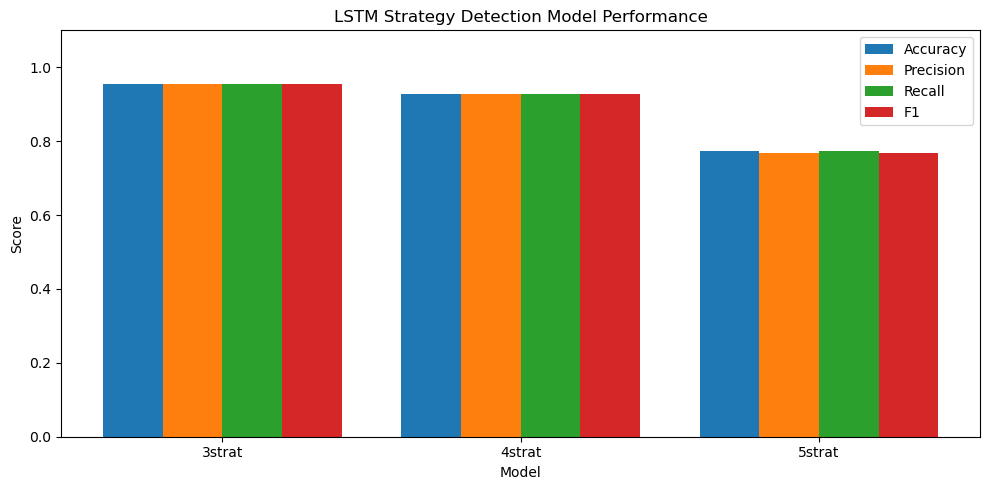

In [13]:
# ============================================================================
# Cell 6: LSTM Model Evaluation (on training data)
# ============================================================================

eval_results = []

for config_name, config in STRATEGY_CONFIGS.items():
    if config_name not in models:
        continue
    
    # Load training data
    existing_files = [f for f in config['train_files'] if f.exists()]
    if not existing_files:
        print(f'No training data for {config_name}')
        continue
    
    data, labels = load_and_parse_data(existing_files)
    X, y, le = extract_features_and_targets(data, labels)
    
    # Split & evaluate
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    y_pred = np.argmax(models[config_name].predict(X_test, verbose=0), axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    eval_results.append({
        'Model': config_name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'N_test': len(y_test)
    })
    print(f'{config_name}: Acc={acc:.4f} Prec={prec:.4f} Rec={rec:.4f} F1={f1:.4f}')

df_eval = pd.DataFrame(eval_results)

# Plot model performance
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(df_eval))
width = 0.2
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, df_eval[metric], width, label=metric)
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('LSTM Strategy Detection Model Performance')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_eval['Model'])
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lstm_model_performance.png', dpi=300)
plt.savefig(FIGURES_DIR / 'lstm_model_performance.pdf')
plt.show()

In [14]:
# ============================================================================
# Cell 7: Prediction Functions
# ============================================================================

def encode_action_sequence(action_string, max_len=10):
    """Encode state-action sequence string to model input format.
    
    Input: 'EC RC RC RC ED' -> Output: [[1, 1.0], [8, 1.0], ...]
    Truncates to first max_len tokens (LSTM trained on 10-round games).
    """
    if pd.isna(action_string) or action_string == '':
        return [[0.0, 0.0]] * max_len
    actions = action_string.strip().split()
    sequence = []
    for action in actions[:max_len]:
        if action in ACTION_MAPPING:
            sequence.append([ACTION_MAPPING[action], 1.0])
        else:
            sequence.append([0.0, 0.0])
    while len(sequence) < max_len:
        sequence.append([0.0, 0.0])
    return sequence


def predict_with_confidence(model, label_encoder, action_sequences):
    """Predict strategy for a batch of action sequences.
    
    Returns: (strategy_names, confidences)
    """
    X = np.array([encode_action_sequence(seq) for seq in action_sequences], dtype=float)
    predictions_proba = model.predict(X, verbose=0)
    predictions_idx = np.argmax(predictions_proba, axis=1)
    confidences = np.max(predictions_proba, axis=1)
    predictions = label_encoder.inverse_transform(predictions_idx)
    return predictions, confidences


def predict_lstm_batch(action_sequences, model, label_encoder):
    """Predict strategies with full confidence details."""
    encoded = [encode_action_sequence(seq) for seq in action_sequences]
    batch_input = np.array(encoded)
    predictions = model.predict(batch_input, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    num_classes = len(label_encoder.classes_)
    predicted_classes = np.clip(predicted_classes, 0, num_classes - 1)
    strategy_names = label_encoder.inverse_transform(predicted_classes)
    
    results = []
    for i, strategy_name in enumerate(strategy_names):
        pred_conf = predictions[i][:num_classes]
        if len(pred_conf) < num_classes:
            pred_conf = np.pad(pred_conf, (0, num_classes - len(pred_conf)))
        confidence = dict(zip(label_encoder.classes_, pred_conf))
        max_prob = max(pred_conf)
        results.append((strategy_name, max_prob, confidence))
    return results

print('Prediction functions ready.')

Prediction functions ready.


In [15]:
# ============================================================================
# Cell 8: Rule-Based Strategy Detection
# ============================================================================

def detect_strategy_by_rules(action_sequence):
    """Detect strategy using strict rule-based logic.
    
    Input: list of state-action codes, e.g. ['EC', 'RC', 'RC', 'SD', 'PD', 'TD']
    Returns: (matched_strategies, confidence)
    """
    if not action_sequence or len(action_sequence) == 0:
        return [], 0
    
    matched_strategies = []
    
    # Extract actions (last char: C or D)
    actions = [a[-1] for a in action_sequence]
    # Extract outcomes/states (first char: R, S, T, P, E)
    outcomes = [a[0] if len(a) >= 2 else None for a in action_sequence]
    
    # --- Rule 1: AllC (always cooperate) ---
    c_count = sum(1 for a in actions if a == 'C')
    if c_count == len(actions):
        matched_strategies.append('AllC')
    
    # --- Rule 2: AllD (always defect) ---
    d_count = sum(1 for a in actions if a == 'D')
    if d_count == len(actions):
        matched_strategies.append('AllD')
    
    # --- Rule 3: TFT (Tit-For-Tat) ---
    if len(action_sequence) >= 4:
        tft_violations = 0
        tft_checks = 0
        
        if actions[0] != 'C':  # TFT starts with C
            tft_violations += 1
            tft_checks += 1
        
        for i in range(1, len(action_sequence)):
            outcome = outcomes[i]
            action = actions[i]
            
            # Opponent cooperated previously (R or T) -> should C
            if outcome in ['R', 'T']:
                tft_checks += 1
                if action != 'C':
                    tft_violations += 1
            # Opponent defected previously (S or P) -> should D
            elif outcome in ['S', 'P']:
                tft_checks += 1
                if action != 'D':
                    tft_violations += 1
        
        # Threshold: >= 85% correct
        if tft_checks > 0 and (1 - tft_violations / tft_checks) >= 0.85:
            matched_strategies.append('TFT')
    
    # --- Rule 4: WSLS (Win-Stay, Lose-Shift) ---
    if len(action_sequence) >= 4:
        wsls_violations = 0
        wsls_checks = 0
        
        for i in range(1, len(action_sequence)):
            prev_outcome = outcomes[i]
            prev_action = actions[i-1]
            current_action = actions[i]
            
            # Win (R=Reward, T=Temptation) -> Stay
            if prev_outcome in ['R', 'T']:
                wsls_checks += 1
                if current_action != prev_action:
                    wsls_violations += 1
            # Lose (S=Sucker, P=Punishment) -> Shift
            elif prev_outcome in ['S', 'P']:
                wsls_checks += 1
                if current_action == prev_action:
                    wsls_violations += 1
        
        if wsls_checks > 0 and (1 - wsls_violations / wsls_checks) >= 0.85:
            matched_strategies.append('WSLS')
    
    if matched_strategies:
        return matched_strategies, 1.0
    
    return [], 0

print('Rule-based detection ready.')

# Quick test
test_seq = 'EC RC RC RC RC RC RC RC RC RC'.split()
print(f'Test AllC sequence: {detect_strategy_by_rules(test_seq)}')
test_seq2 = 'ED PD PD PD PD PD PD PD PD PD'.split()
print(f'Test AllD sequence: {detect_strategy_by_rules(test_seq2)}')
test_seq3 = 'EC RC SC PD TD RC SC PD TD RC'.split()
print(f'Test TFT-like seq:  {detect_strategy_by_rules(test_seq3)}')

Rule-based detection ready.
Test AllC sequence: (['AllC', 'TFT', 'WSLS'], 1.0)
Test AllD sequence: (['AllD', 'TFT'], 1.0)
Test TFT-like seq:  ([], 0)


In [44]:
# ============================================================================
# Cell 9: Combined Prediction Pipeline (LSTM + Rule-Based)
# ============================================================================
# Strategy: Use 4-strategy LSTM as primary, then rule-based override

SELECTED_MODEL = '4strat'
model = models[SELECTED_MODEL]
label_encoder = encoders[SELECTED_MODEL]

print(f'Using {SELECTED_MODEL} LSTM model with strategies: {list(label_encoder.classes_)}')

# Build agent-level DataFrame
agent_rows = []

for idx, row in df_games.iterrows():
    for agent_num in [1, 2]:
        agent_prefix = f'agent{agent_num}'
        opp_num = 2 if agent_num == 1 else 1
        
        agent_rows.append({
            'game_id': row['game_id'],
            'llm_name': row['llm_name'],
            'noise_level': row['noise_level'],
            'language': row['language'],
            'agent_name': row[f'{agent_prefix}_name'],
            'personality': row[f'{agent_prefix}_personality'],
            'noise_rate': row[f'{agent_prefix}_noise_rate'],
            'total_score': row[f'{agent_prefix}_total_score'],
            'cooperation_rate': row[f'{agent_prefix}_cooperation_rate'],
            'defection_rate': row[f'{agent_prefix}_defection_rate'],
            'flipped_count': row[f'{agent_prefix}_flipped_count'],
            'strategies': row[f'{agent_prefix}_strategies'],
            'intended_strategies': row[f'{agent_prefix}_intended_strategies'],
            'opponent_strategies': row[f'agent{opp_num}_strategies'],
            'opponent_personality': row[f'agent{opp_num}_personality'],
            'state_action_seq': row[f'state_action_agent{agent_num}'],
            'time_checker_accuracy': row.get('time_checker_accuracy', np.nan),
            'rule_checker_accuracy': row.get('rule_checker_accuracy', np.nan),
            'aggregation_checker_accuracy': row.get('aggregation_checker_accuracy', np.nan),
        })

agent_df = pd.DataFrame(agent_rows)
print(f'Agent-level DataFrame: {agent_df.shape} ({len(agent_df)} agent records)')

# ---- LSTM Predictions ----
print('\nRunning LSTM predictions...')
action_sequences = agent_df['state_action_seq'].tolist()
lstm_results = predict_lstm_batch(action_sequences, model, label_encoder)

strategy_names = [r[0] for r in lstm_results]
probabilities = [r[1] for r in lstm_results]

# ---- Rule-Based Override ----
print('Applying rule-based override...')
override_count = 0

for i, sa_seq in enumerate(action_sequences):
    if sa_seq and sa_seq != '':
        tokens = sa_seq.strip().split()
        rule_strategies, rule_confidence = detect_strategy_by_rules(tokens)
        if rule_strategies:
            strategy_names[i] = '|'.join(rule_strategies)
            probabilities[i] = rule_confidence
            override_count += 1

agent_df['predicted_strategy'] = strategy_names
agent_df['prediction_confidence'] = probabilities

print(f'Total agents: {len(agent_df)}')
print(f'Rule-based overrides: {override_count} ({override_count/len(agent_df)*100:.1f}%)')
print(f'\nStrategy distribution (all):')
print(agent_df['predicted_strategy'].value_counts())

Using 4strat LSTM model with strategies: [np.str_('AllC'), np.str_('AllD'), np.str_('TFT'), np.str_('WSLS')]
Agent-level DataFrame: (3360, 19) (3360 agent records)

Running LSTM predictions...
Applying rule-based override...
Total agents: 3360
Rule-based overrides: 2156 (64.2%)

Strategy distribution (all):
predicted_strategy
TFT              837
AllD|TFT         663
AllD             612
AllC             558
AllC|TFT|WSLS    280
WSLS             150
AllD|WSLS        138
TFT|WSLS         122
Name: count, dtype: int64


In [17]:
# ============================================================================
# Cell 10: Filter by Confidence & Expand Composite Strategies
# ============================================================================

CONFIDENCE_THRESHOLD = 0.9
df_main = agent_df[agent_df['prediction_confidence'] >= CONFIDENCE_THRESHOLD].copy()
print(f'Agents with confidence >= {CONFIDENCE_THRESHOLD}: {len(df_main)} / {len(agent_df)} '
      f'({len(df_main)/len(agent_df)*100:.1f}%)')

# Expand composite strategies (e.g., 'AllC|TFT') into separate rows
expanded_rows = []
for idx, row in df_main.iterrows():
    strategies = row['predicted_strategy'].split('|')
    for strat in strategies:
        new_row = row.copy()
        new_row['predicted_strategy'] = strat.strip()
        expanded_rows.append(new_row)

df_all = pd.DataFrame(expanded_rows).reset_index(drop=True)

# Categorize cooperation type
def categorize_cooperation(strategy):
    if strategy in ['AllC']:
        return 'Unconditional Cooperation'
    elif strategy in ['AllD']:
        return 'Unconditional Defection'
    elif strategy in ['TFT', 'WSLS', 'GTFT']:
        return 'Conditional Cooperation'
    else:
        return 'Other'

df_all['cooperation_type'] = df_all['predicted_strategy'].apply(categorize_cooperation)

print(f'\nExpanded DataFrame: {len(df_all)} rows')
print(f'\nStrategy distribution (expanded, confidence >= {CONFIDENCE_THRESHOLD}):')
print(df_all['predicted_strategy'].value_counts())
print(f'\nCooperation type distribution:')
print(df_all['cooperation_type'].value_counts())

Agents with confidence >= 0.9: 3128 / 3360 (93.1%)

Expanded DataFrame: 4611 rows

Strategy distribution (expanded, confidence >= 0.9):
predicted_strategy
TFT     1825
AllD    1366
AllC     778
WSLS     642
Name: count, dtype: int64

Cooperation type distribution:
cooperation_type
Conditional Cooperation      2467
Unconditional Defection      1366
Unconditional Cooperation     778
Name: count, dtype: int64


---
## Part III: Behavioral Profile Analysis (from nicer_than_humans)

In [ ]:
# ============================================================================
# Cell 11: Compute Behavioral Profiles for All Agents
# ============================================================================

def strategies_to_binary(strategy_str):
    """Convert multilingual strategy string to [1, 0, 1, ...] binary list.
    Handles: C/D (English), C/T (French), H/P (Vietnamese), 合/背 (Chinese), ت/خ (Arabic)
    """
    if pd.isna(strategy_str) or strategy_str == '':
        return []
    return [1 if normalize_action(s.strip()) == 'C' else 0 for s in strategy_str.split(',')]


# Compute behavioral dimensions for every agent
print('Computing behavioral profiles for all agents...')

profile_data = []
for idx, row in agent_df.iterrows():
    main_hist = strategies_to_binary(row['strategies'])
    opp_hist = strategies_to_binary(row['opponent_strategies'])
    
    if len(main_hist) < 2 or len(opp_hist) < 2:
        continue
    
    # Ensure same length
    min_len = min(len(main_hist), len(opp_hist))
    main_hist = main_hist[:min_len]
    opp_hist = opp_hist[:min_len]
    
    profile = {
        'game_id': row['game_id'],
        'agent_name': row['agent_name'],
        'llm_name': row['llm_name'],
        'noise_level': row['noise_level'],
        'personality': row['personality'],
        'cooperation_rate': row['cooperation_rate'],
        'predicted_strategy': row['predicted_strategy'],
        'prediction_confidence': row['prediction_confidence'],
        'nice': compute_niceness(main_hist, opp_hist),
        'forgiving': compute_forgiveness(main_hist, opp_hist),
        'retaliatory': compute_retaliation(main_hist, opp_hist),
        'troublemaking': compute_troublemaking(main_hist, opp_hist),
        'emulative': compute_emulation(main_hist, opp_hist),
    }
    profile_data.append(profile)

df_profiles = pd.DataFrame(profile_data)
print(f'Behavioral profiles computed: {len(df_profiles)} agents')

# Summary by model
dims = ['nice', 'forgiving', 'retaliatory', 'troublemaking', 'emulative']
print(f'\n--- Behavioral Profile by LLM ---')
print(df_profiles.groupby('llm_name')[dims].mean().round(3).to_string())

print(f'\n--- Behavioral Profile by Personality ---')
print(df_profiles.groupby('personality')[dims].mean().round(3).to_string())


print(f'\n--- Behavioral Profile by Noise Level ---')print(df_profiles.groupby('noise_level')[dims].mean().round(3).to_string())

Computing behavioral profiles for all agents...
Behavioral profiles computed: 3360 agents

--- Behavioral Profile by LLM ---
                           nice  forgiving  retaliatory  troublemaking  emulative
llm_name                                                                         
Mistral-7B-Instruct-v0.3  0.216      0.219        0.657          0.746      0.776
Qwen2.5-32B-Instruct      0.203      0.231        0.705          0.756      0.815
gpt-oss-20b               0.140      0.125        0.895          0.860      0.957

--- Behavioral Profile by Personality ---
                    nice  forgiving  retaliatory  troublemaking  emulative
personality                                                               
cooperative        0.636      0.555        0.395          0.272      0.726
cooperativo        0.768      0.679        0.318          0.135      0.629
coopératif         0.750      0.571        0.348          0.157      0.699
egoista            0.046      0.187        0.58

---
## Part IV: SFEM Analysis

In [19]:
# ============================================================================
# Cell 12: Compute SFEM Scores
# ============================================================================

print('Computing SFEM scores...')
print('(This may take a few minutes due to optimization)\n')

sfem_results = []

for llm_name in df_games['llm_name'].unique():
    for noise_level in sorted(df_games['noise_level'].unique()):
        subset = df_games[
            (df_games['llm_name'] == llm_name) & 
            (df_games['noise_level'] == noise_level)
        ]
        
        if len(subset) == 0:
            continue
        
        # Prepare game histories for SFEM
        for agent_num in [1, 2]:
            game_histories = []
            for _, row in subset.iterrows():
                main_hist = strategies_to_binary(row[f'agent{agent_num}_strategies'])
                opp_num = 2 if agent_num == 1 else 1
                opp_hist = strategies_to_binary(row[f'agent{opp_num}_strategies'])
                
                if len(main_hist) > 0 and len(opp_hist) > 0:
                    min_len = min(len(main_hist), len(opp_hist))
                    game_histories.append({
                        'main_history': main_hist[:min_len],
                        'opponent_history': opp_hist[:min_len]
                    })
            
            if len(game_histories) == 0:
                continue
            
            scores, labels = compute_sfem(game_histories, n_restarts=30)
            
            for lbl, score in zip(labels, scores):
                sfem_results.append({
                    'llm_name': llm_name,
                    'noise_level': noise_level,
                    'agent': f'agent{agent_num}',
                    'strategy': lbl,
                    'sfem_score': score,
                })
        
        print(f'  {llm_name} noise={noise_level}: done ({len(subset)} games)')

df_sfem = pd.DataFrame(sfem_results)
print(f'\nSFEM computation complete: {len(df_sfem)} score entries')

# Show average SFEM by model
sfem_pivot = df_sfem.groupby(['llm_name', 'strategy'])['sfem_score'].mean().unstack(fill_value=0)
print('\n--- Average SFEM Scores by LLM ---')
print(sfem_pivot.round(3).to_string())

Computing SFEM scores...
(This may take a few minutes due to optimization)

  Mistral-7B-Instruct-v0.3 noise=0: done (240 games)
  Mistral-7B-Instruct-v0.3 noise=5: done (240 games)
  Qwen2.5-32B-Instruct noise=0: done (240 games)
  Qwen2.5-32B-Instruct noise=5: done (240 games)
  Qwen2.5-32B-Instruct noise=20: done (240 games)
  gpt-oss-20b noise=0: done (240 games)
  gpt-oss-20b noise=5: done (240 games)

SFEM computation complete: 98 score entries

--- Average SFEM Scores by LLM ---
strategy                     AC     AD   GRIM    RND   STFT    TFT   WSLS
llm_name                                                                 
Mistral-7B-Instruct-v0.3  0.185  0.449  0.031  0.002  0.288  0.029  0.016
Qwen2.5-32B-Instruct      0.165  0.459  0.046  0.002  0.281  0.034  0.014
gpt-oss-20b               0.007  0.513  0.101  0.002  0.315  0.057  0.003


---
## Part V: Cooperation Rate Analysis

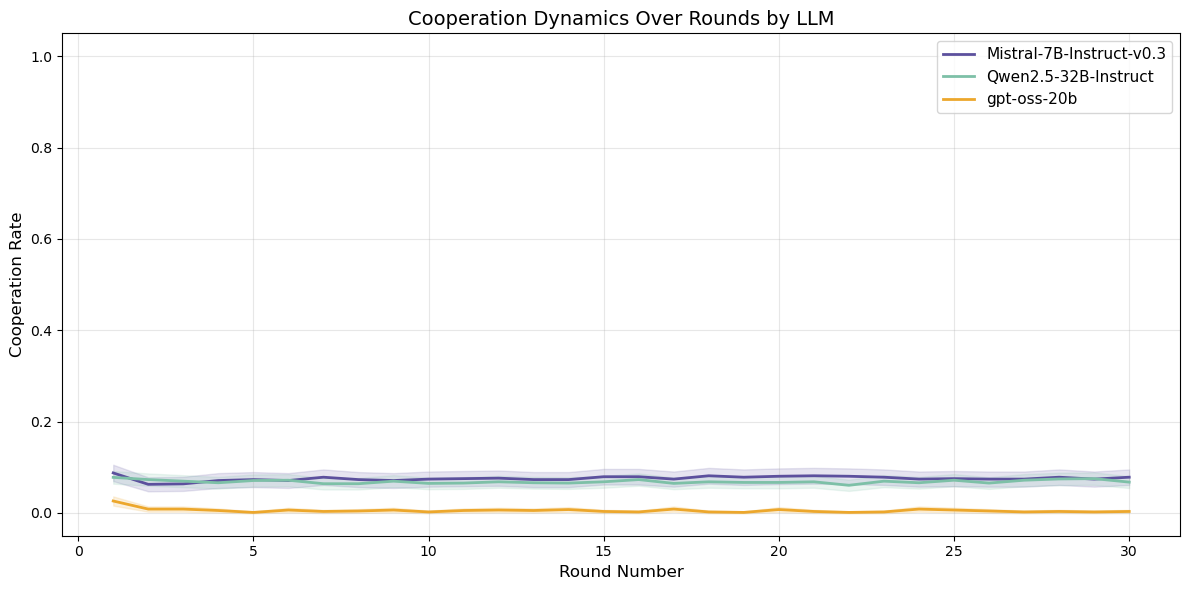

In [20]:
# ============================================================================
# Cell 13: Cooperation Dynamics Over Rounds
# ============================================================================

def compute_per_round_cooperation(df_rounds_data, groupby_col='llm_name'):
    """Compute average cooperation rate per round, grouped by a column."""
    df_coop = df_rounds_data.copy()
    df_coop['is_cooperate'] = (df_coop['final_strategy'] == 'Cooperate').astype(int)
    
    result = df_coop.groupby([groupby_col, 'round_number'])['is_cooperate'].agg(
        ['mean', 'std', 'count']
    ).reset_index()
    result.columns = [groupby_col, 'round_number', 'coop_rate', 'coop_std', 'n']
    
    # 95% CI
    result['ci'] = 1.96 * result['coop_std'] / np.sqrt(result['n'])
    return result

# By LLM
coop_by_model = compute_per_round_cooperation(df_rounds, 'llm_name')

fig, ax = plt.subplots(figsize=(12, 6))
for model_name in coop_by_model['llm_name'].unique():
    data = coop_by_model[coop_by_model['llm_name'] == model_name]
    color = MODEL_COLORS.get(model_name, '#333')
    ax.plot(data['round_number'], data['coop_rate'], label=model_name, color=color, linewidth=2)
    ax.fill_between(data['round_number'],
                    data['coop_rate'] - data['ci'],
                    data['coop_rate'] + data['ci'],
                    alpha=0.15, color=color)

ax.set_xlabel('Round Number', fontsize=12)
ax.set_ylabel('Cooperation Rate', fontsize=12)
ax.set_title('Cooperation Dynamics Over Rounds by LLM', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cooperation_dynamics_by_model.png', dpi=300)
plt.savefig(FIGURES_DIR / 'cooperation_dynamics_by_model.pdf')
plt.show()

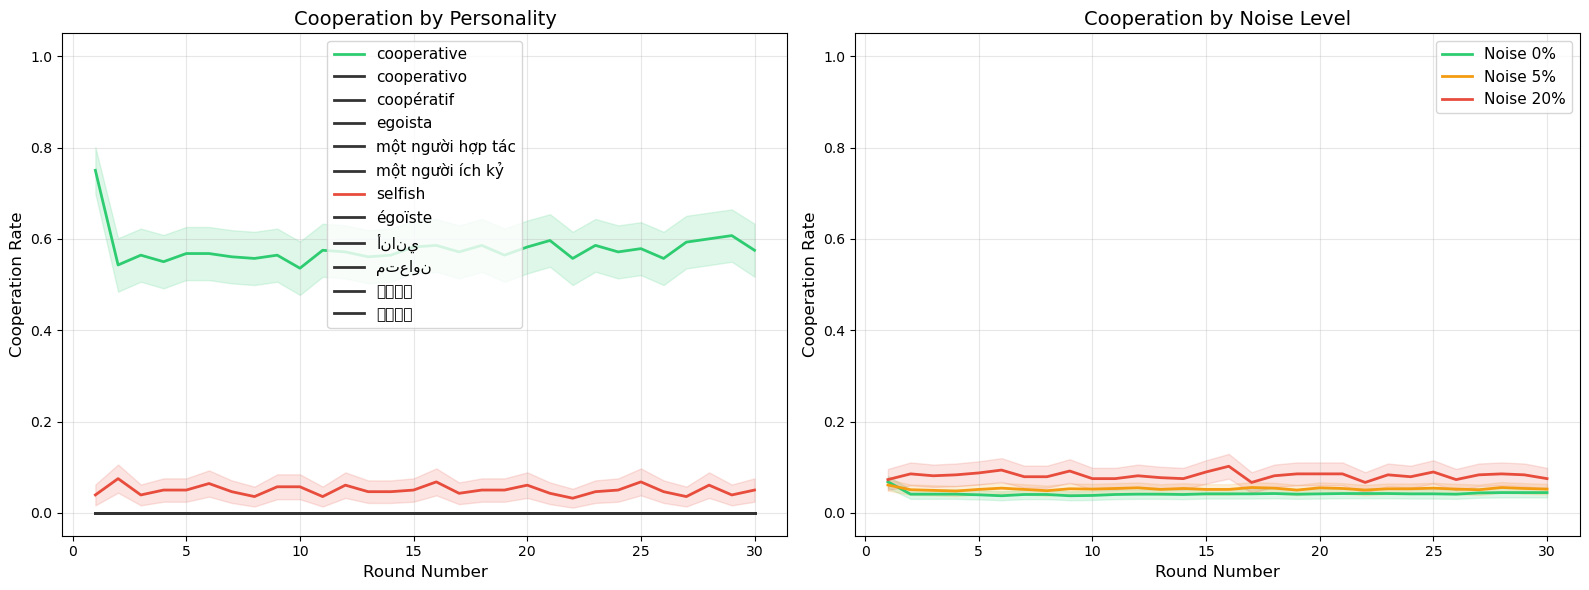

In [21]:
# ============================================================================
# Cell 14: Cooperation by Personality & Noise
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By Personality
coop_by_personality = compute_per_round_cooperation(df_rounds, 'agent_personality')
ax = axes[0]
for personality in coop_by_personality['agent_personality'].unique():
    data = coop_by_personality[coop_by_personality['agent_personality'] == personality]
    color = PERSONALITY_COLORS.get(personality, '#333')
    ax.plot(data['round_number'], data['coop_rate'], label=personality, color=color, linewidth=2)
    ax.fill_between(data['round_number'],
                    data['coop_rate'] - data['ci'],
                    data['coop_rate'] + data['ci'],
                    alpha=0.15, color=color)
ax.set_xlabel('Round Number', fontsize=12)
ax.set_ylabel('Cooperation Rate', fontsize=12)
ax.set_title('Cooperation by Personality', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

# By Noise Level
coop_by_noise = compute_per_round_cooperation(df_rounds, 'noise_level')
ax = axes[1]
noise_colors = {0: '#2ecc71', 5: '#f39c12', 20: '#e74c3c'}
for noise in sorted(coop_by_noise['noise_level'].unique()):
    data = coop_by_noise[coop_by_noise['noise_level'] == noise]
    color = noise_colors.get(noise, '#333')
    ax.plot(data['round_number'], data['coop_rate'], 
            label=f'Noise {noise}%', color=color, linewidth=2)
    ax.fill_between(data['round_number'],
                    data['coop_rate'] - data['ci'],
                    data['coop_rate'] + data['ci'],
                    alpha=0.15, color=color)
ax.set_xlabel('Round Number', fontsize=12)
ax.set_ylabel('Cooperation Rate', fontsize=12)
ax.set_title('Cooperation by Noise Level', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cooperation_dynamics_personality_noise.png', dpi=300)
plt.savefig(FIGURES_DIR / 'cooperation_dynamics_personality_noise.pdf')
plt.show()

---
## Part VI: Paper-Ready Visualizations

In [22]:
# ============================================================================
# Cell 15: Publication Style Setup
# ============================================================================

# Paper figure dimensions (single column = 3.33", double column = 6.75")
SINGLE_COL = 3.33
DOUBLE_COL = 6.75
DPI = 300

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': DPI,
    'savefig.dpi': DPI,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

def get_strategy_distribution(df, group_col=None):
    """Get strategy distribution, optionally grouped."""
    if group_col:
        return df.groupby([group_col, 'predicted_strategy']).size().unstack(fill_value=0)
    return df['predicted_strategy'].value_counts()

print('Publication style configured.')

Publication style configured.


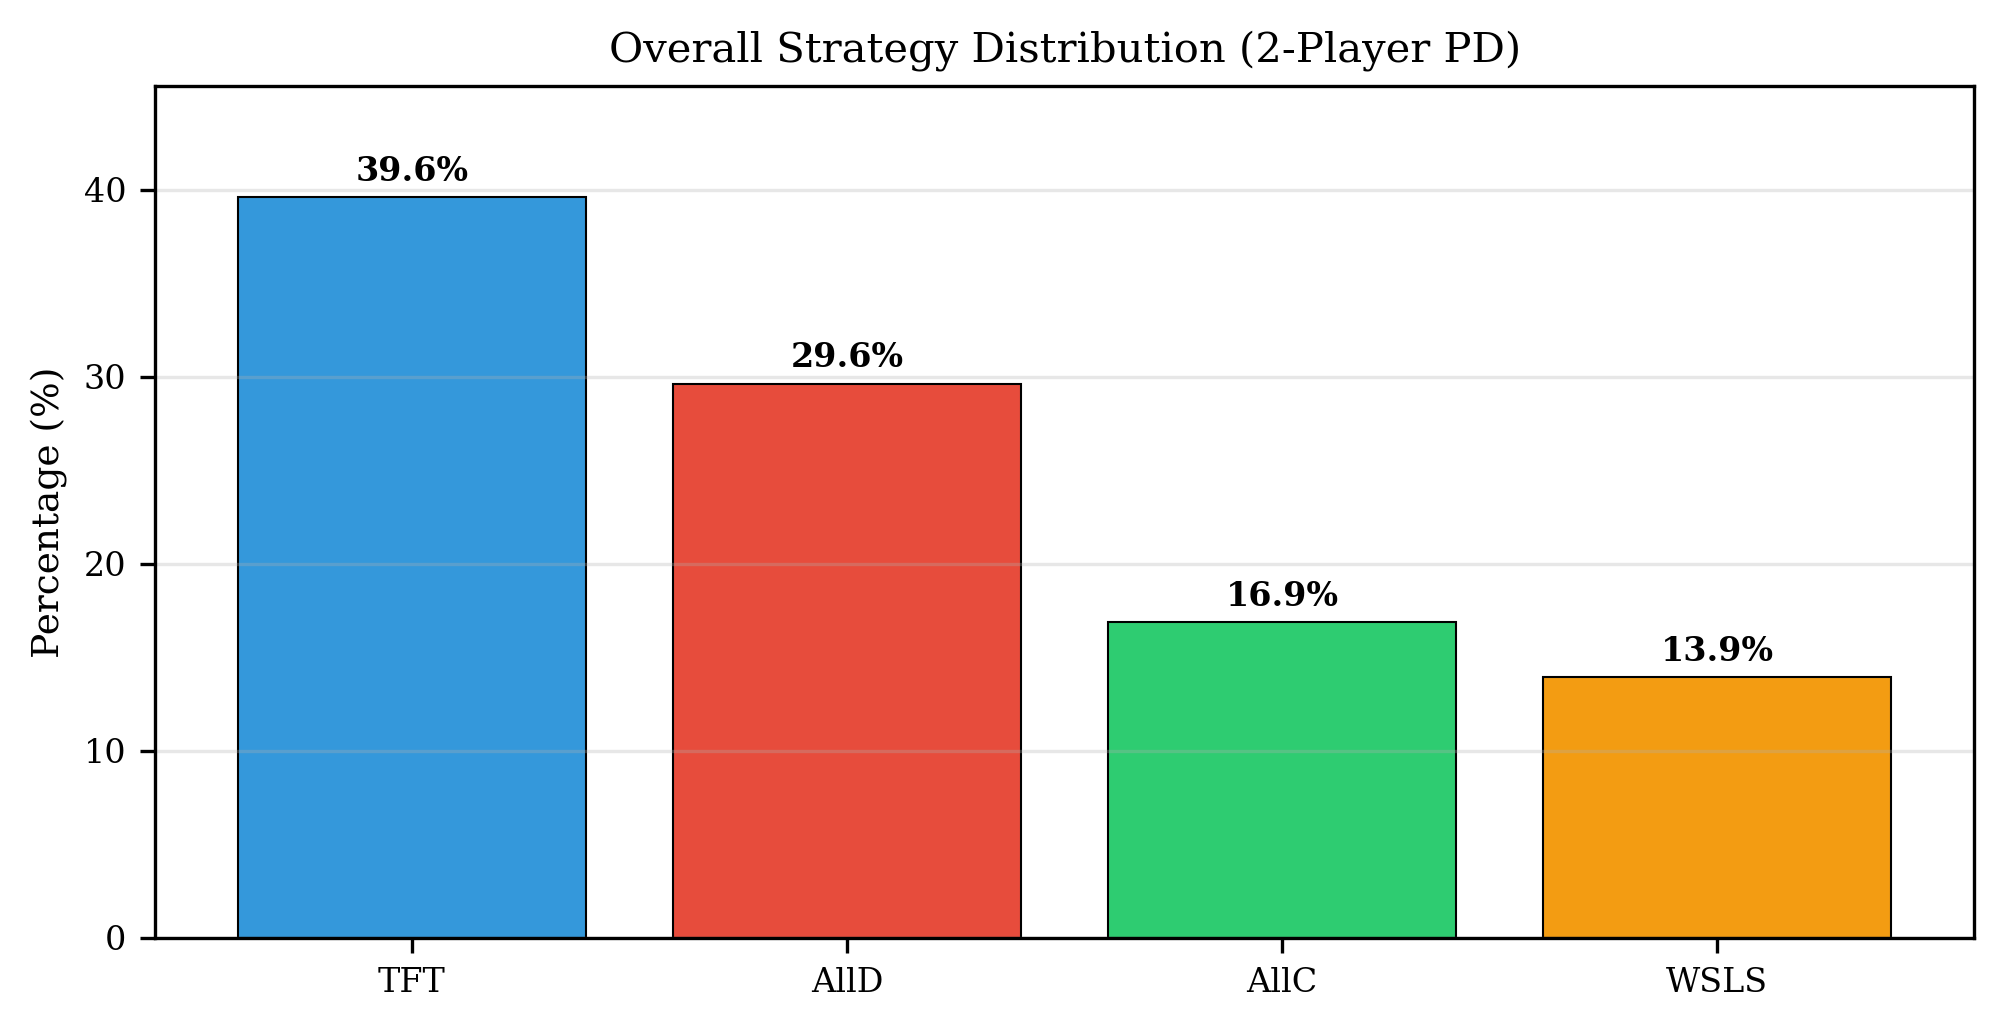

Total agents analyzed: 4611
predicted_strategy
TFT     1825
AllD    1366
AllC     778
WSLS     642
Name: count, dtype: int64


In [23]:
# ============================================================================
# Cell 16: Fig 1 - Overall Strategy Distribution
# ============================================================================

fig, ax = plt.subplots(figsize=(DOUBLE_COL, 3.5))

strat_counts = df_all['predicted_strategy'].value_counts()
strat_pcts = strat_counts / strat_counts.sum() * 100
colors = [STRATEGY_COLORS.get(s, '#95a5a6') for s in strat_pcts.index]

bars = ax.bar(strat_pcts.index, strat_pcts.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, pct in zip(bars, strat_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Percentage (%)')
ax.set_title('Overall Strategy Distribution (2-Player PD)')
ax.set_ylim(0, max(strat_pcts.values) * 1.15)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_overall_strategy_distribution.png', dpi=DPI)
plt.savefig(FIGURES_DIR / 'fig1_overall_strategy_distribution.pdf')
plt.show()

print(f'Total agents analyzed: {len(df_all)}')
print(strat_counts)

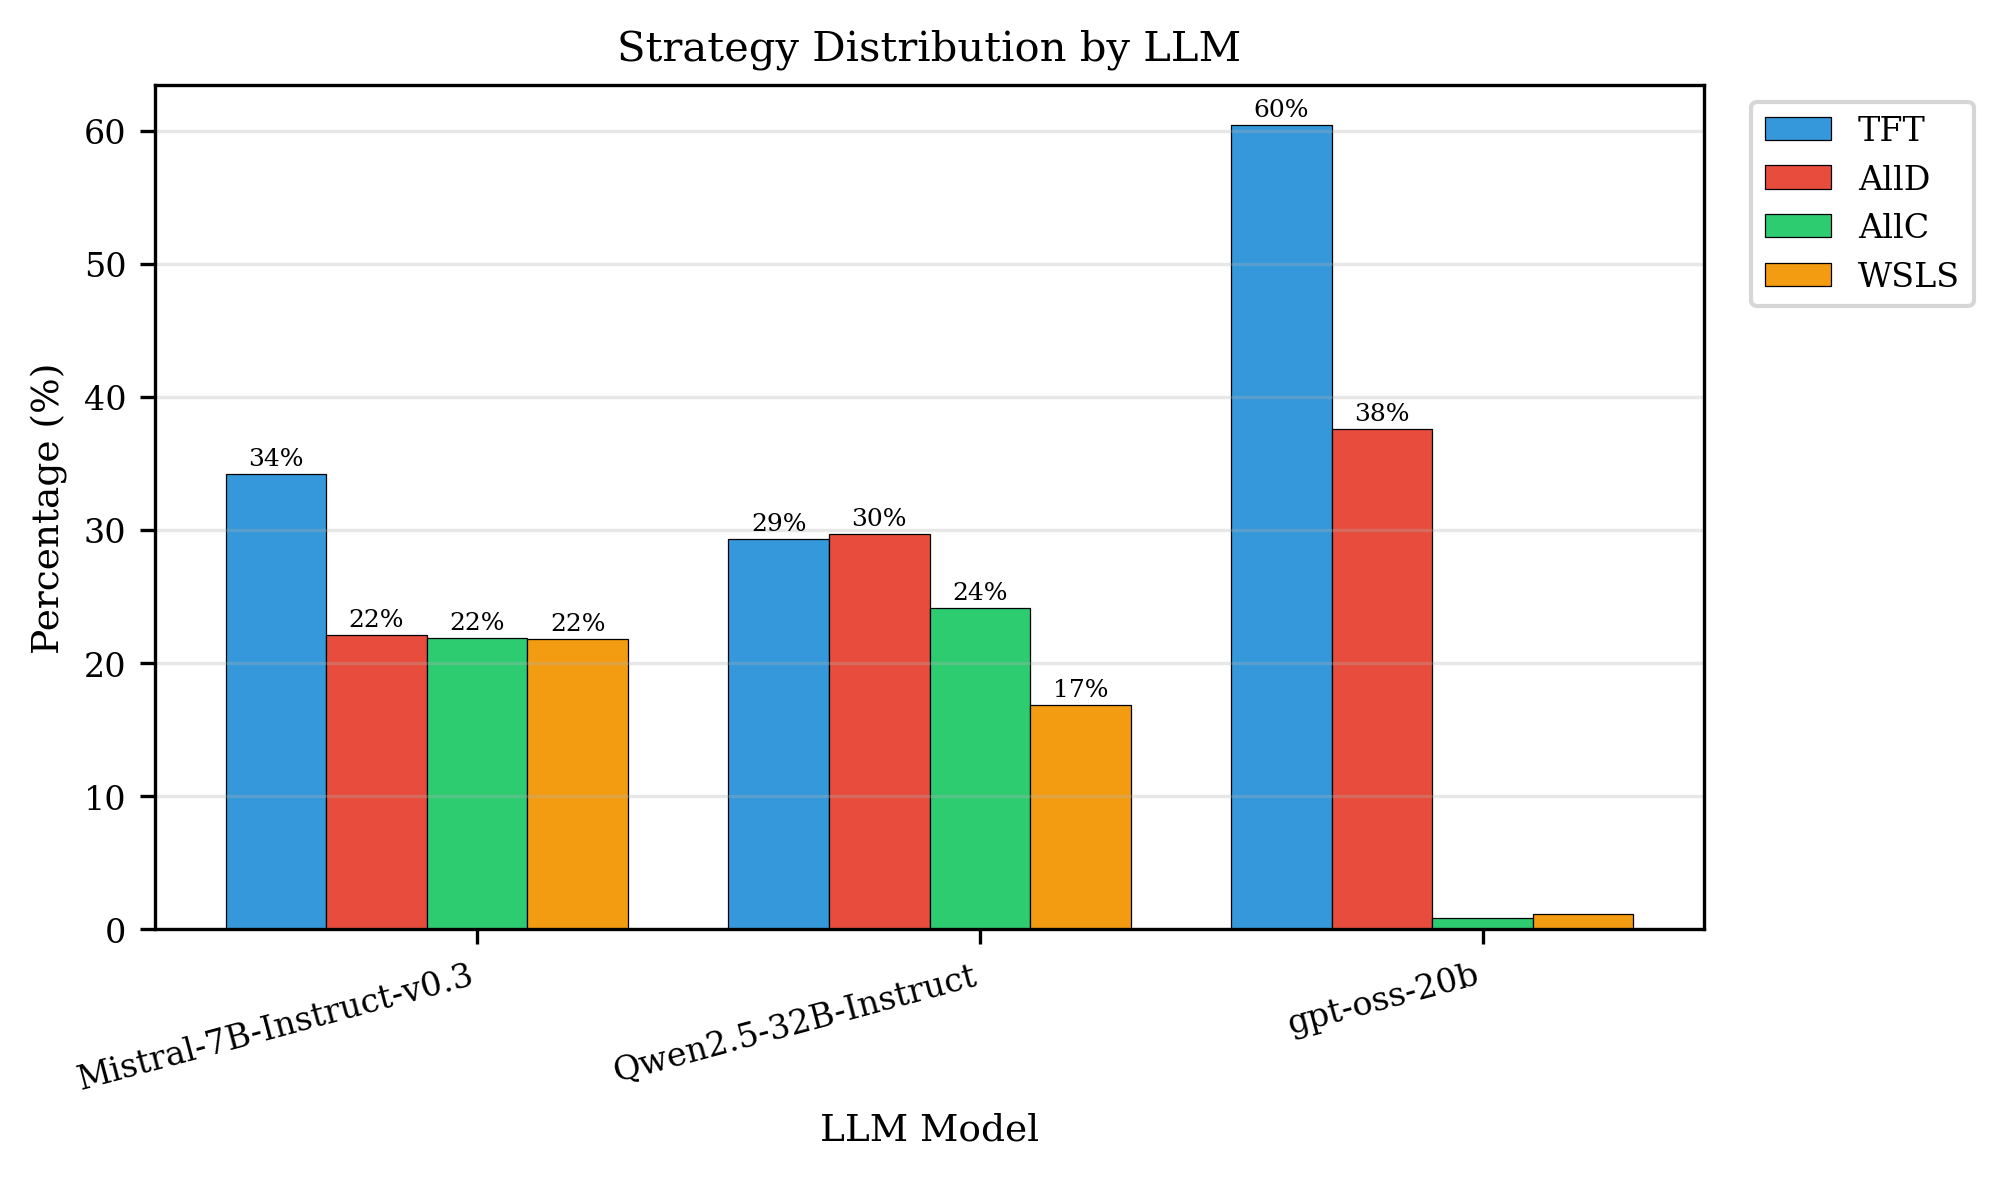

In [24]:
# ============================================================================
# Cell 17: Fig 2 - Strategy Distribution by LLM
# ============================================================================

fig, ax = plt.subplots(figsize=(DOUBLE_COL, 4))

strat_by_llm = df_all.groupby(['llm_name', 'predicted_strategy']).size().unstack(fill_value=0)
# Normalize to percentages per LLM
strat_pct_llm = strat_by_llm.div(strat_by_llm.sum(axis=1), axis=0) * 100

strategies_order = strat_counts.index.tolist()
# Ensure all strategies are present
for s in strategies_order:
    if s not in strat_pct_llm.columns:
        strat_pct_llm[s] = 0
strat_pct_llm = strat_pct_llm[strategies_order]

x = np.arange(len(strat_pct_llm.index))
width = 0.8 / len(strategies_order)

for i, strat in enumerate(strategies_order):
    color = STRATEGY_COLORS.get(strat, '#95a5a6')
    bars = ax.bar(x + i * width, strat_pct_llm[strat].values, width,
                  label=strat, color=color, edgecolor='black', linewidth=0.3)
    for bar, val in zip(bars, strat_pct_llm[strat].values):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=6)

ax.set_xlabel('LLM Model')
ax.set_ylabel('Percentage (%)')
ax.set_title('Strategy Distribution by LLM')
ax.set_xticks(x + width * len(strategies_order) / 2)
ax.set_xticklabels(strat_pct_llm.index, rotation=15, ha='right')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_strategy_by_llm.png', dpi=DPI)
plt.savefig(FIGURES_DIR / 'fig2_strategy_by_llm.pdf')
plt.show()

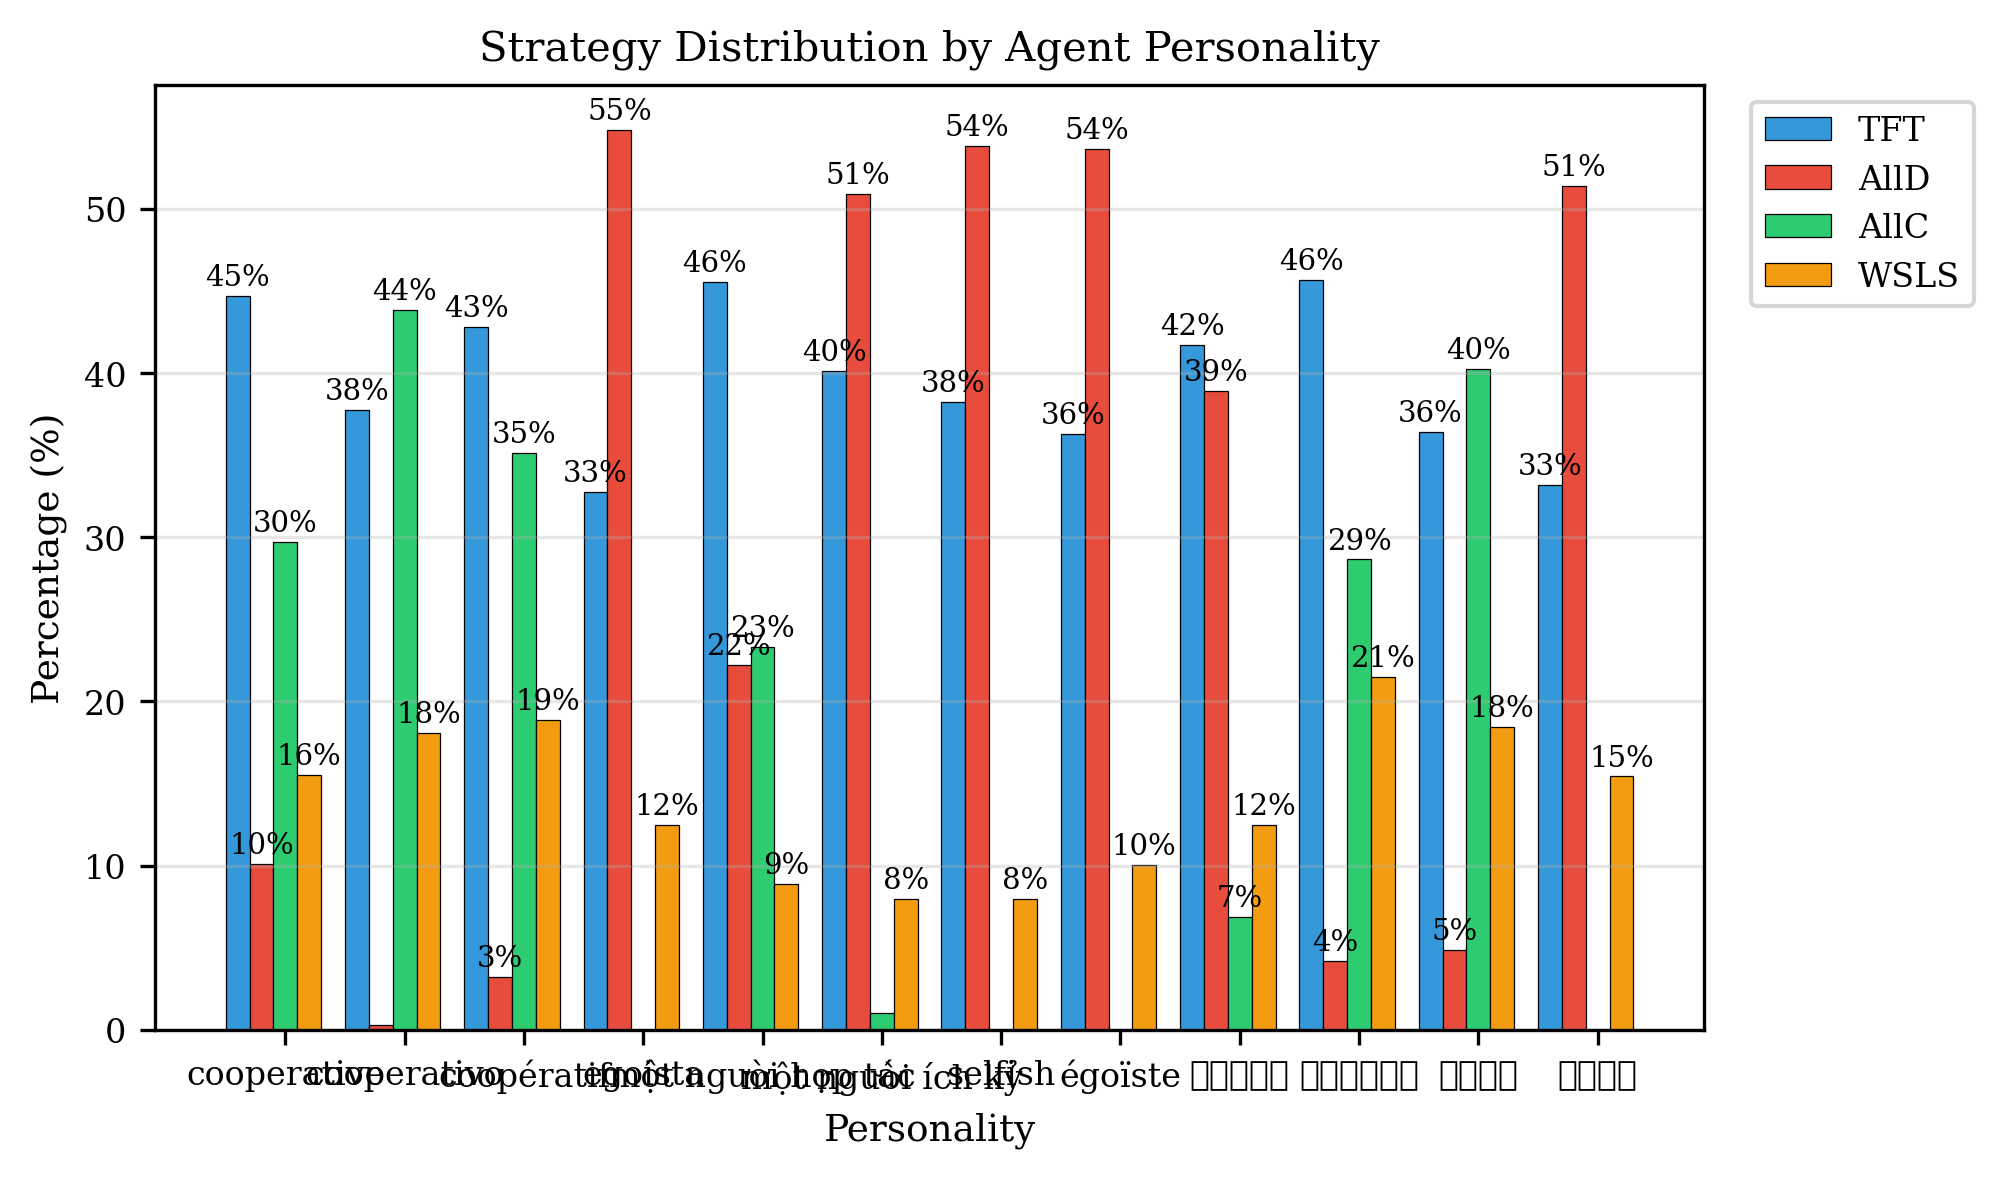

In [25]:
# ============================================================================
# Cell 18: Fig 3 - Strategy Distribution by Personality
# ============================================================================

fig, ax = plt.subplots(figsize=(DOUBLE_COL, 4))

strat_by_pers = df_all.groupby(['personality', 'predicted_strategy']).size().unstack(fill_value=0)
strat_pct_pers = strat_by_pers.div(strat_by_pers.sum(axis=1), axis=0) * 100

for s in strategies_order:
    if s not in strat_pct_pers.columns:
        strat_pct_pers[s] = 0
strat_pct_pers = strat_pct_pers[strategies_order]

x = np.arange(len(strat_pct_pers.index))
width = 0.8 / len(strategies_order)

for i, strat in enumerate(strategies_order):
    color = STRATEGY_COLORS.get(strat, '#95a5a6')
    bars = ax.bar(x + i * width, strat_pct_pers[strat].values, width,
                  label=strat, color=color, edgecolor='black', linewidth=0.3)
    for bar, val in zip(bars, strat_pct_pers[strat].values):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
                    f'{val:.0f}%', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Personality')
ax.set_ylabel('Percentage (%)')
ax.set_title('Strategy Distribution by Agent Personality')
ax.set_xticks(x + width * len(strategies_order) / 2)
ax.set_xticklabels(strat_pct_pers.index)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_strategy_by_personality.png', dpi=DPI)
plt.savefig(FIGURES_DIR / 'fig3_strategy_by_personality.pdf')
plt.show()

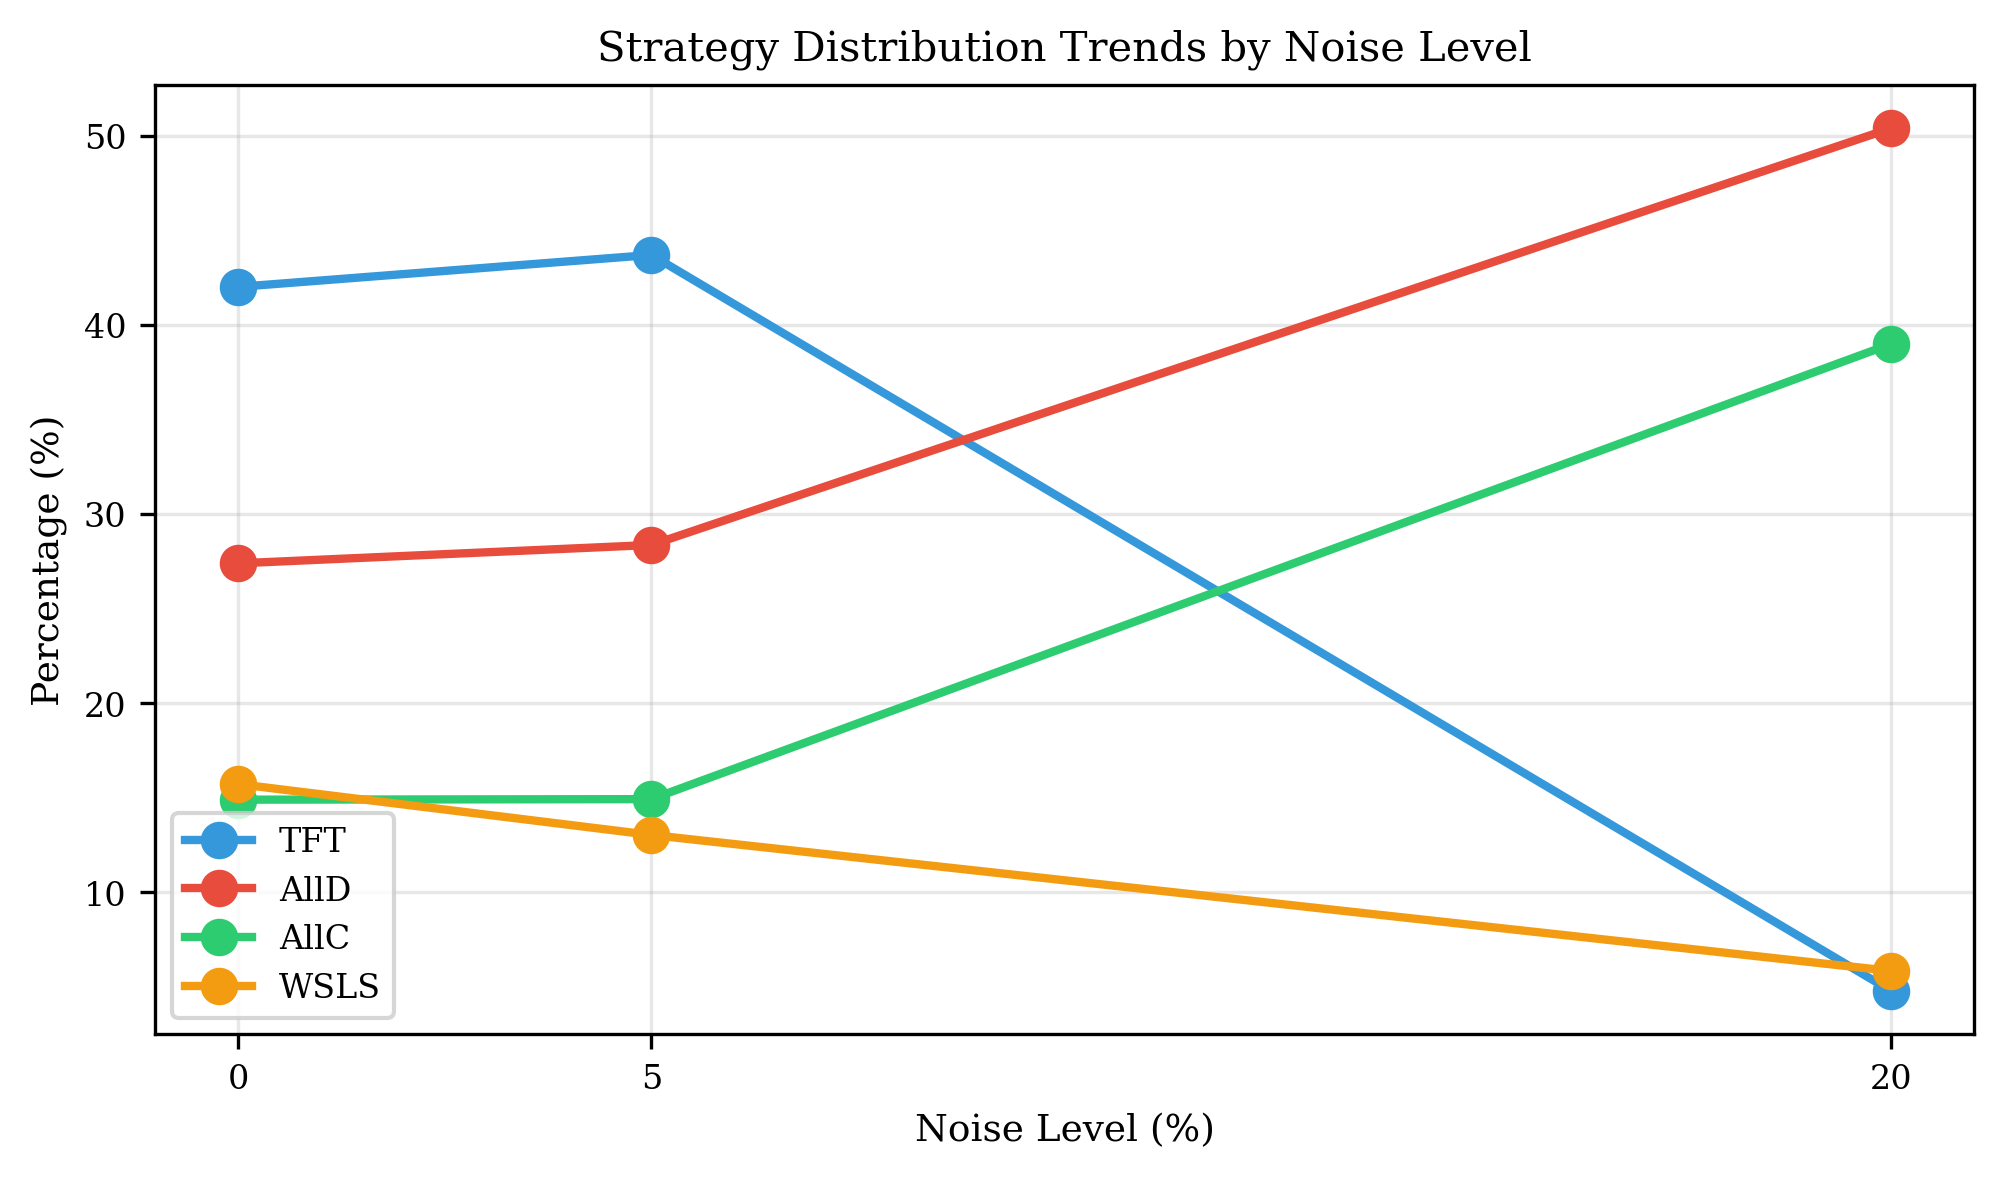

In [26]:
# ============================================================================
# Cell 19: Fig 4 - Strategy Trends by Noise Level
# ============================================================================

fig, ax = plt.subplots(figsize=(DOUBLE_COL, 4))

noise_levels = sorted(df_all['noise_level'].unique())

for strat in strategies_order:
    pcts = []
    for noise in noise_levels:
        subset = df_all[df_all['noise_level'] == noise]
        total = len(subset)
        count = len(subset[subset['predicted_strategy'] == strat])
        pcts.append(count / total * 100 if total > 0 else 0)
    
    color = STRATEGY_COLORS.get(strat, '#95a5a6')
    ax.plot(noise_levels, pcts, 'o-', label=strat, color=color, linewidth=2, markersize=8)

ax.set_xlabel('Noise Level (%)')
ax.set_ylabel('Percentage (%)')
ax.set_title('Strategy Distribution Trends by Noise Level')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(noise_levels)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_strategy_trends_by_noise.png', dpi=DPI)
plt.savefig(FIGURES_DIR / 'fig4_strategy_trends_by_noise.pdf')
plt.show()

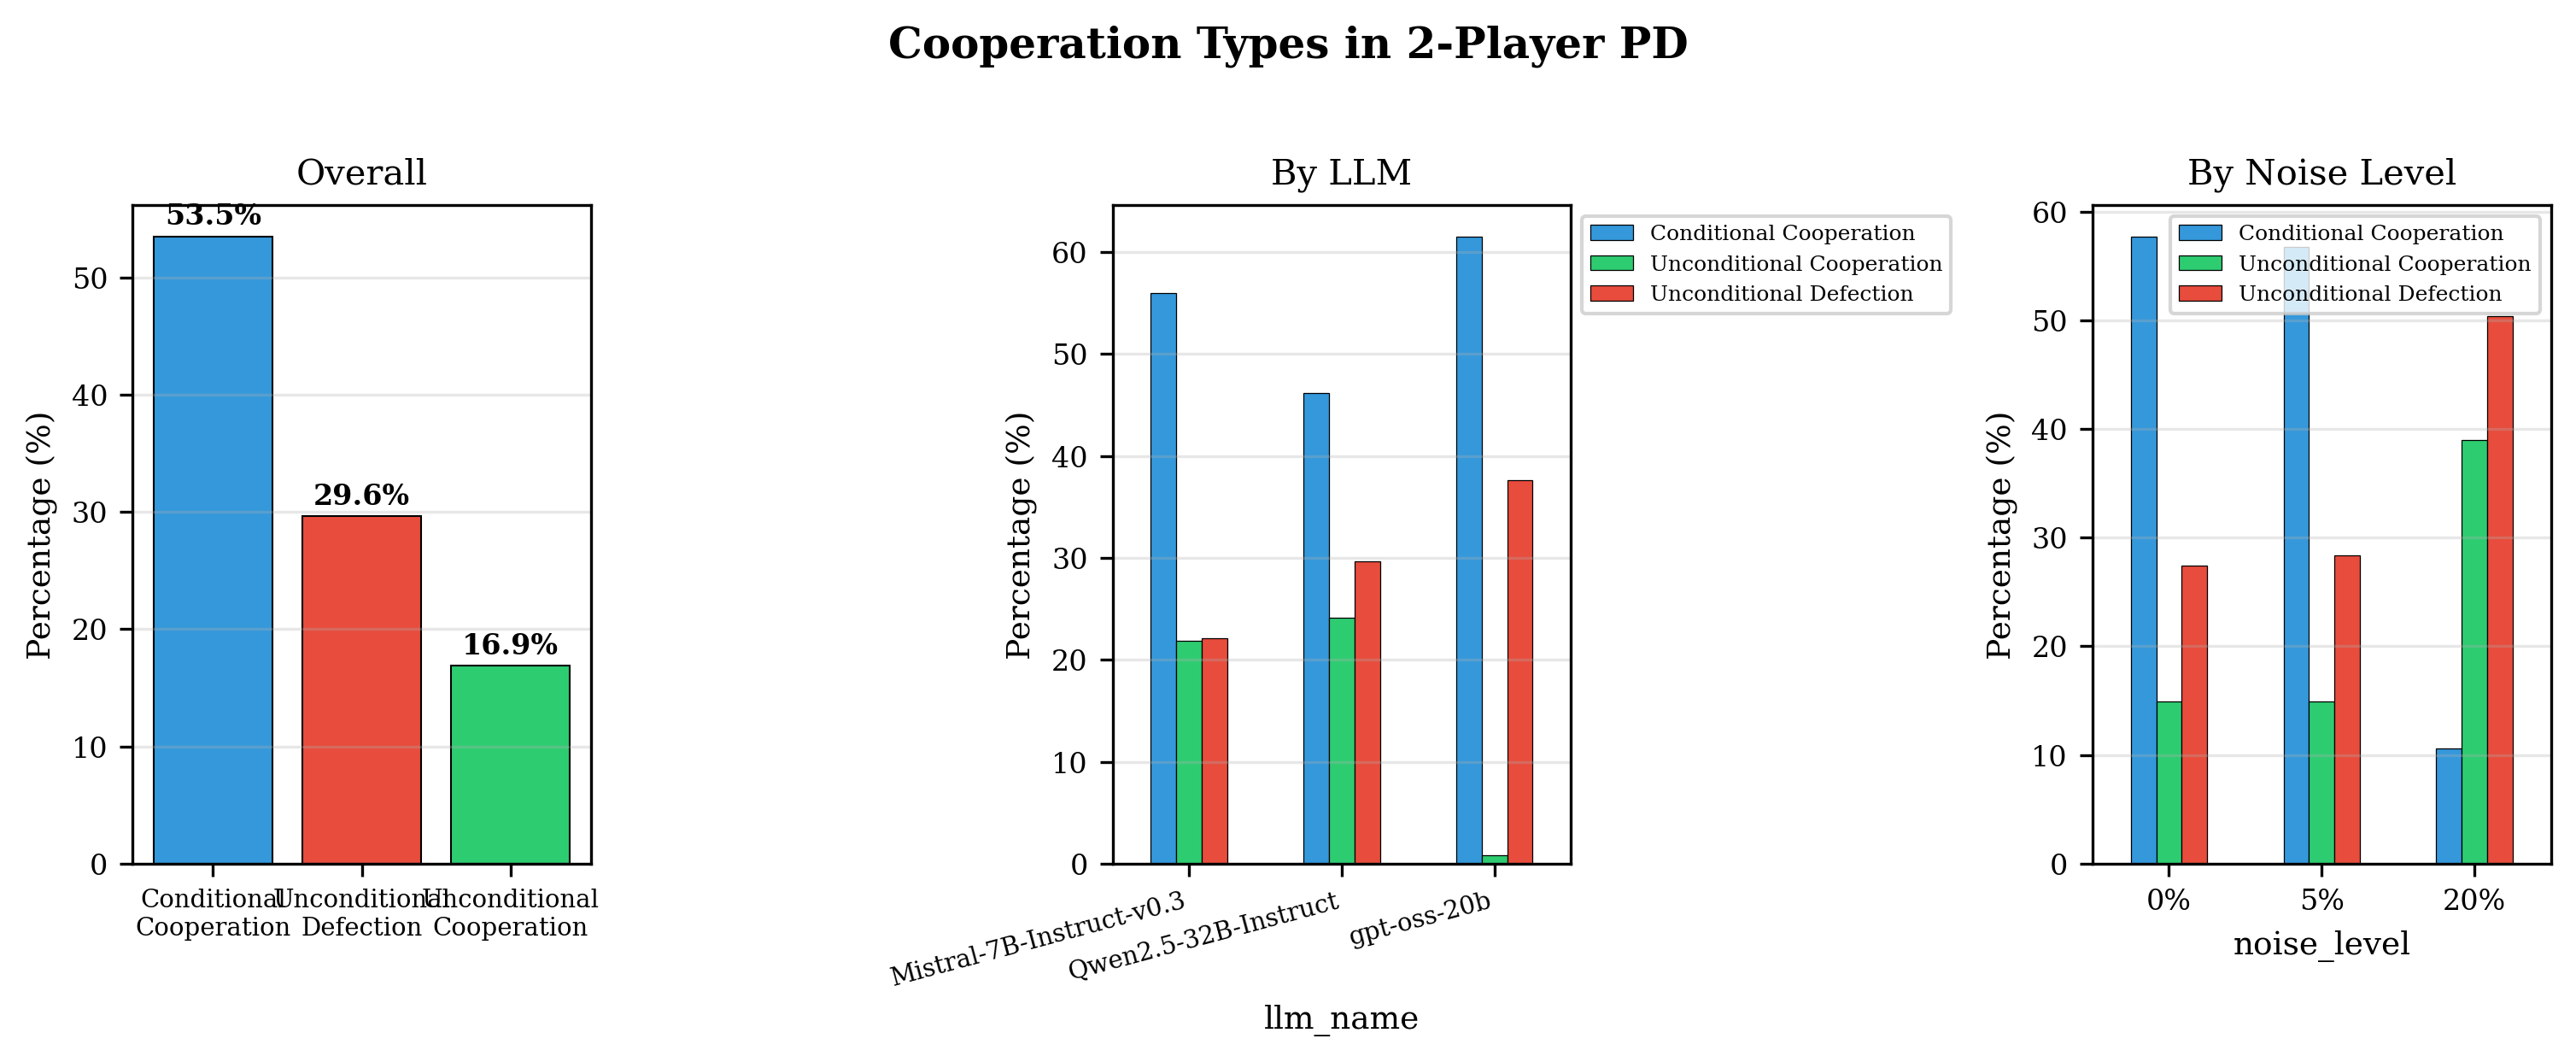

In [27]:
# ============================================================================
# Cell 20: Fig 5 - Cooperation Types (Unconditional/Conditional/Defection)
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL * 1.5, 4))

coop_type_colors = {
    'Unconditional Cooperation': '#2ecc71',
    'Conditional Cooperation': '#3498db',
    'Unconditional Defection': '#e74c3c',
    'Other': '#95a5a6',
}

# Overall
ax = axes[0]
ct_counts = df_all['cooperation_type'].value_counts()
ct_pcts = ct_counts / ct_counts.sum() * 100
colors = [coop_type_colors.get(c, '#95a5a6') for c in ct_pcts.index]
bars = ax.bar(range(len(ct_pcts)), ct_pcts.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(ct_pcts)))
ax.set_xticklabels([c.replace(' ', '\n') for c in ct_pcts.index], fontsize=7)
for bar, pct in zip(bars, ct_pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_title('Overall')
ax.grid(axis='y', alpha=0.3)

# By LLM
ax = axes[1]
ct_by_llm = df_all.groupby(['llm_name', 'cooperation_type']).size().unstack(fill_value=0)
ct_pct_llm = ct_by_llm.div(ct_by_llm.sum(axis=1), axis=0) * 100
ct_pct_llm.plot(kind='bar', ax=ax, color=[coop_type_colors.get(c, '#95a5a6') for c in ct_pct_llm.columns],
                edgecolor='black', linewidth=0.3)
ax.set_ylabel('Percentage (%)')
ax.set_title('By LLM')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=7)
ax.legend(fontsize=6, bbox_to_anchor=(1.0, 1.0))
ax.grid(axis='y', alpha=0.3)

# By Noise Level
ax = axes[2]
ct_by_noise = df_all.groupby(['noise_level', 'cooperation_type']).size().unstack(fill_value=0)
ct_pct_noise = ct_by_noise.div(ct_by_noise.sum(axis=1), axis=0) * 100
ct_pct_noise.plot(kind='bar', ax=ax, color=[coop_type_colors.get(c, '#95a5a6') for c in ct_pct_noise.columns],
                  edgecolor='black', linewidth=0.3)
ax.set_ylabel('Percentage (%)')
ax.set_title('By Noise Level')
ax.set_xticklabels([f'{int(x.get_text())}%' for x in ax.get_xticklabels()], rotation=0)
ax.legend(fontsize=6)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cooperation Types in 2-Player PD', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_cooperation_types_combined.png', dpi=DPI, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig5_cooperation_types_combined.pdf', bbox_inches='tight')
plt.show()

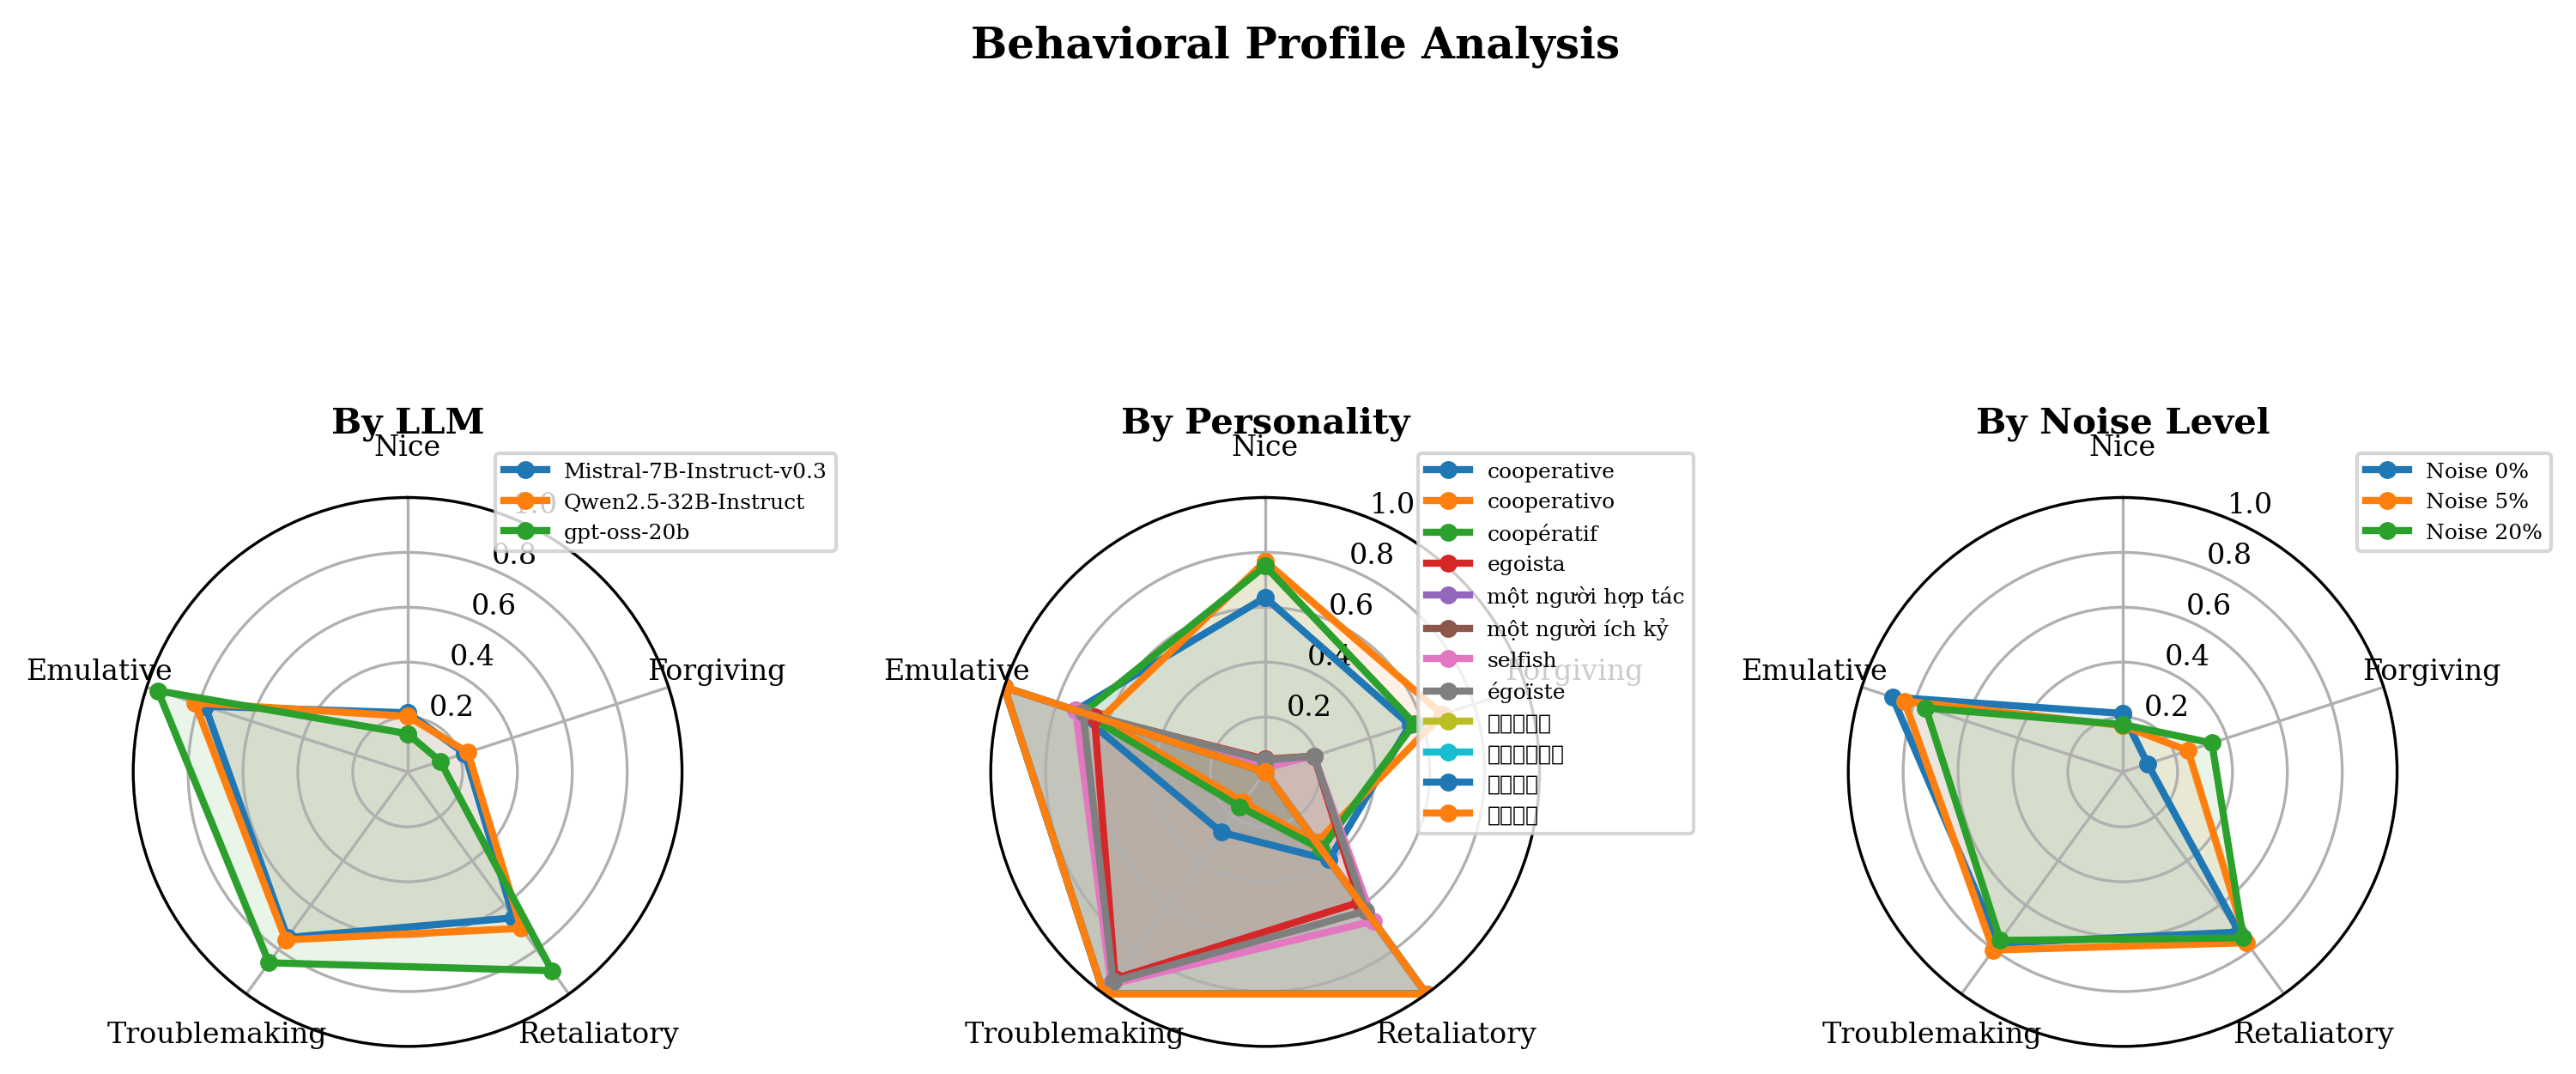

In [28]:
# ============================================================================
# Cell 21: Fig 6 - Behavioral Profile Radar Charts
# ============================================================================

def plot_radar_chart(ax, categories, values_dict, title=''):
    """Plot a radar/spider chart."""
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=8)
    
    for label, values in values_dict.items():
        vals = list(values) + [values[0]]
        ax.plot(angles, vals, 'o-', linewidth=2, label=label, markersize=4)
        ax.fill(angles, vals, alpha=0.1)
    
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=10, fontweight='bold', y=1.08)


# Radar by LLM
fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL * 1.5, 5),
                         subplot_kw={'projection': 'polar'})

categories = ['Nice', 'Forgiving', 'Retaliatory', 'Troublemaking', 'Emulative']
dim_cols = ['nice', 'forgiving', 'retaliatory', 'troublemaking', 'emulative']

# Overall radar by LLM
llm_profiles = df_profiles.groupby('llm_name')[dim_cols].mean()
values_dict = {llm: llm_profiles.loc[llm].values for llm in llm_profiles.index}
plot_radar_chart(axes[0], categories, values_dict, 'By LLM')
axes[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=6)

# Radar by Personality
pers_profiles = df_profiles.groupby('personality')[dim_cols].mean()
values_dict = {p: pers_profiles.loc[p].values for p in pers_profiles.index}
plot_radar_chart(axes[1], categories, values_dict, 'By Personality')
axes[1].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=6)

# Radar by Noise Level
noise_profiles = df_profiles.groupby('noise_level')[dim_cols].mean()
values_dict = {f'Noise {int(n)}%': noise_profiles.loc[n].values for n in noise_profiles.index}
plot_radar_chart(axes[2], categories, values_dict, 'By Noise Level')
axes[2].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=6)

plt.suptitle('Behavioral Profile Analysis', fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig6_behavioral_radar_charts.png', dpi=DPI, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig6_behavioral_radar_charts.pdf', bbox_inches='tight')
plt.show()

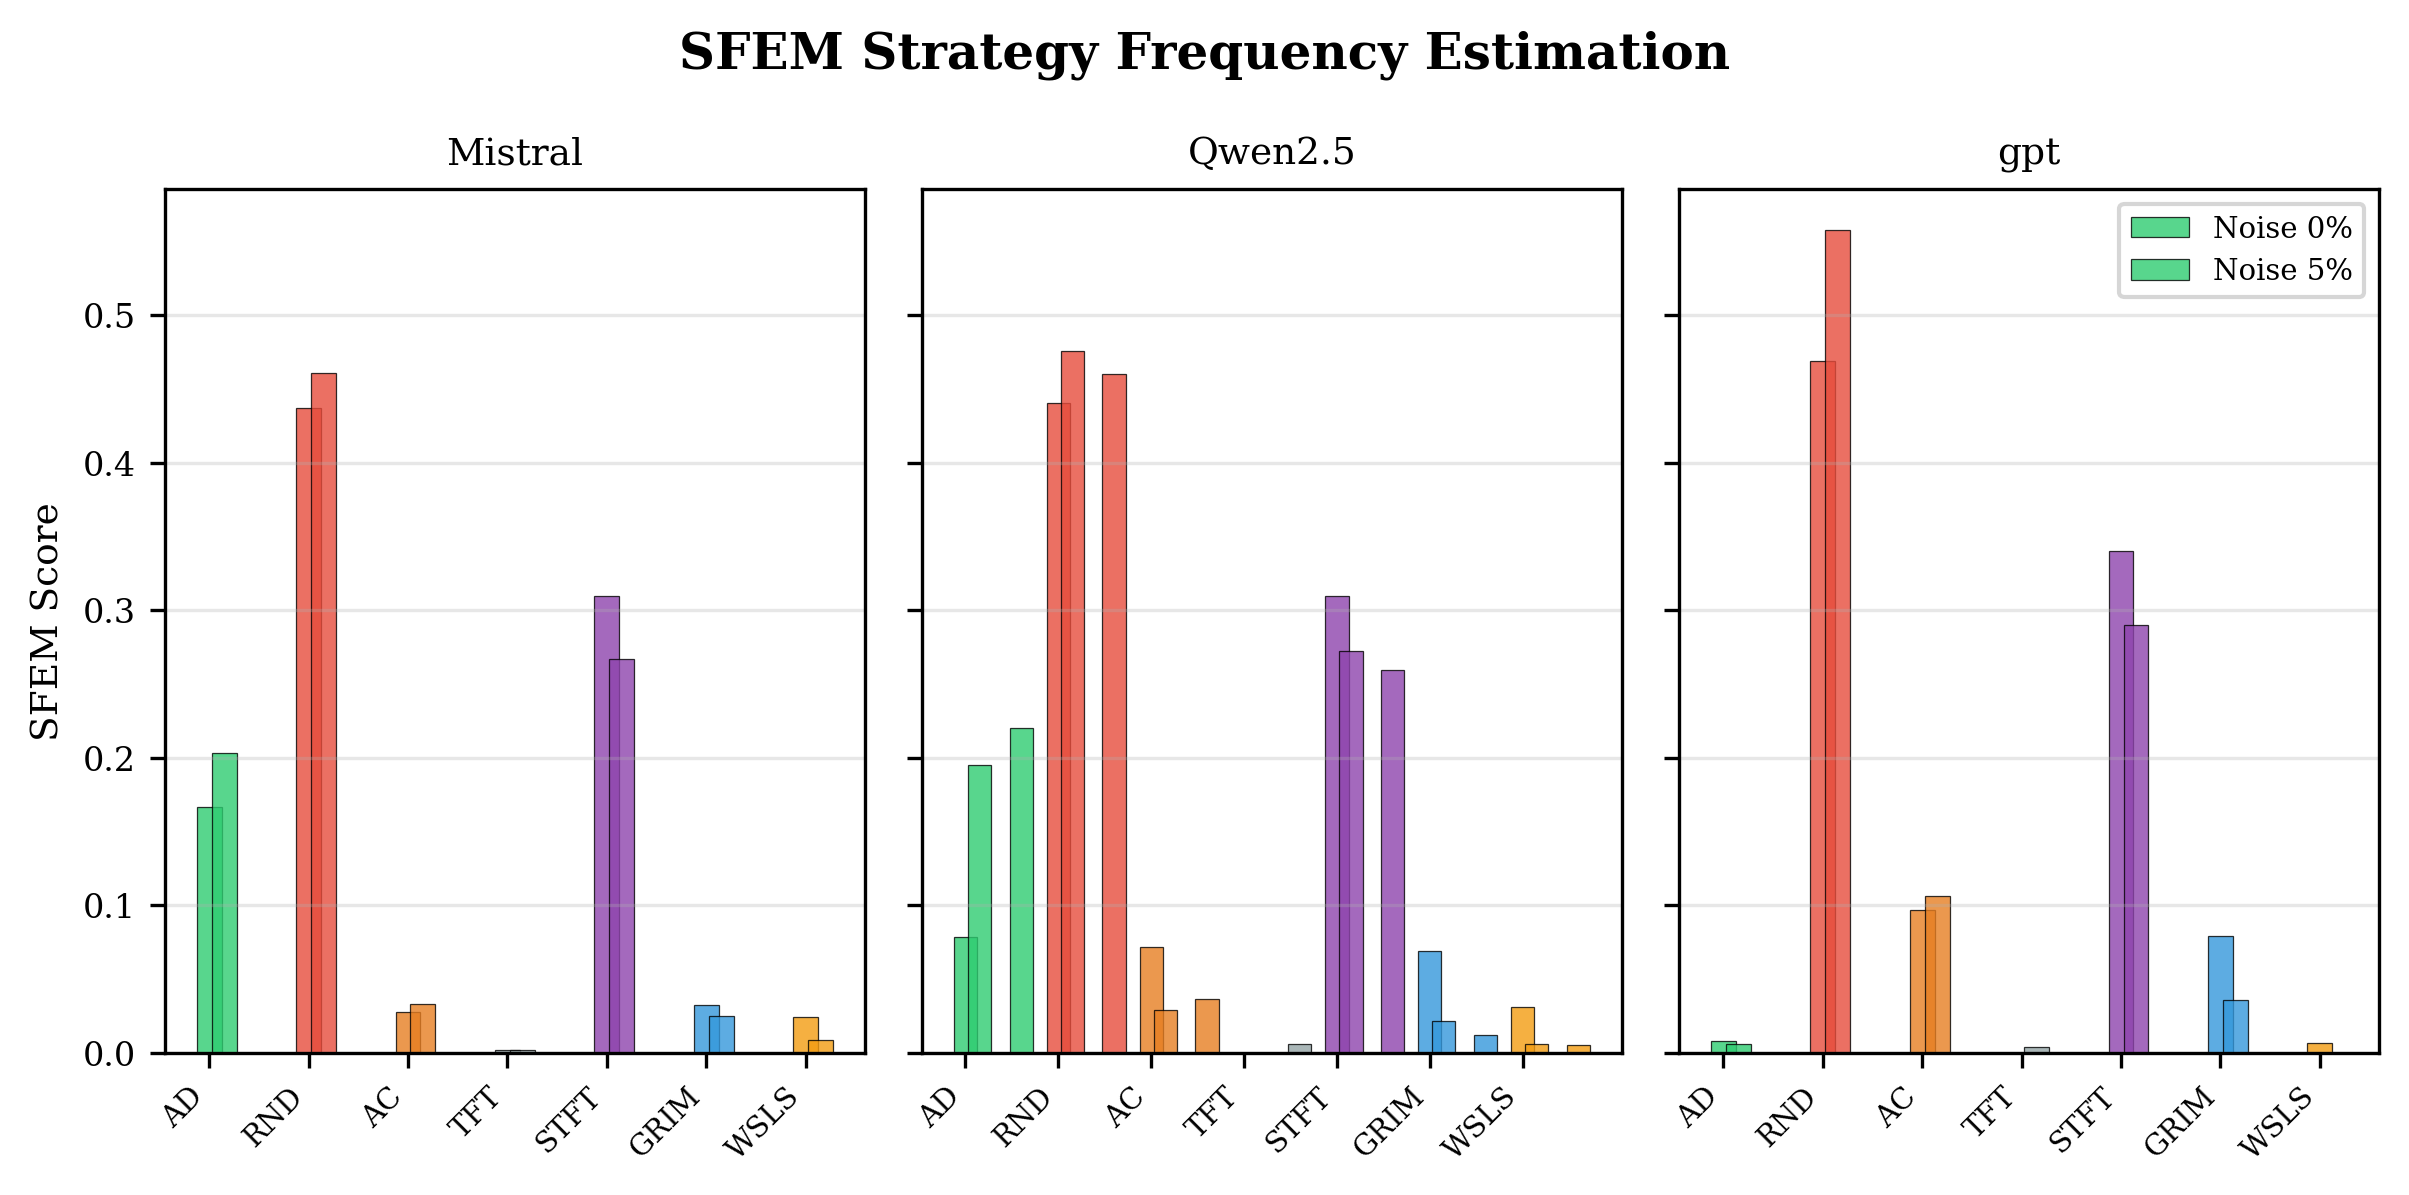

In [29]:
# ============================================================================
# Cell 22: Fig 7 - SFEM Results Visualization
# ============================================================================

if len(df_sfem) > 0:
    fig, axes = plt.subplots(1, len(df_sfem['llm_name'].unique()), 
                             figsize=(DOUBLE_COL * 1.2, 4), sharey=True)
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    
    sfem_strategies = df_sfem['strategy'].unique()
    sfem_strat_colors = {
        'AC': '#2ecc71', 'AD': '#e74c3c', 'TFT': '#3498db',
        'STFT': '#8e44ad', 'GRIM': '#e67e22', 'WSLS': '#f39c12', 'RND': '#95a5a6'
    }
    
    for ax_idx, llm in enumerate(df_sfem['llm_name'].unique()):
        ax = axes[ax_idx]
        llm_sfem = df_sfem[df_sfem['llm_name'] == llm]
        
        for noise in sorted(llm_sfem['noise_level'].unique()):
            noise_data = llm_sfem[llm_sfem['noise_level'] == noise]
            avg_scores = noise_data.groupby('strategy')['sfem_score'].mean()
            
            x_pos = np.arange(len(avg_scores))
            colors = [sfem_strat_colors.get(s, '#333') for s in avg_scores.index]
            
            offset = noise / 100  # small offset for grouped bars
            ax.bar(x_pos + offset * 3, avg_scores.values, width=0.25,
                   label=f'Noise {noise}%', alpha=0.8,
                   color=colors, edgecolor='black', linewidth=0.3)
        
        ax.set_title(llm.split('-')[0] if '-' in llm else llm, fontsize=9)
        ax.set_xticks(np.arange(len(sfem_strategies)))
        ax.set_xticklabels(sfem_strategies, rotation=45, ha='right', fontsize=7)
        ax.grid(axis='y', alpha=0.3)
        if ax_idx == 0:
            ax.set_ylabel('SFEM Score')
    
    axes[-1].legend(fontsize=7)
    plt.suptitle('SFEM Strategy Frequency Estimation', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig7_sfem_results.png', dpi=DPI)
    plt.savefig(FIGURES_DIR / 'fig7_sfem_results.pdf')
    plt.show()
else:
    print('No SFEM results to plot.')

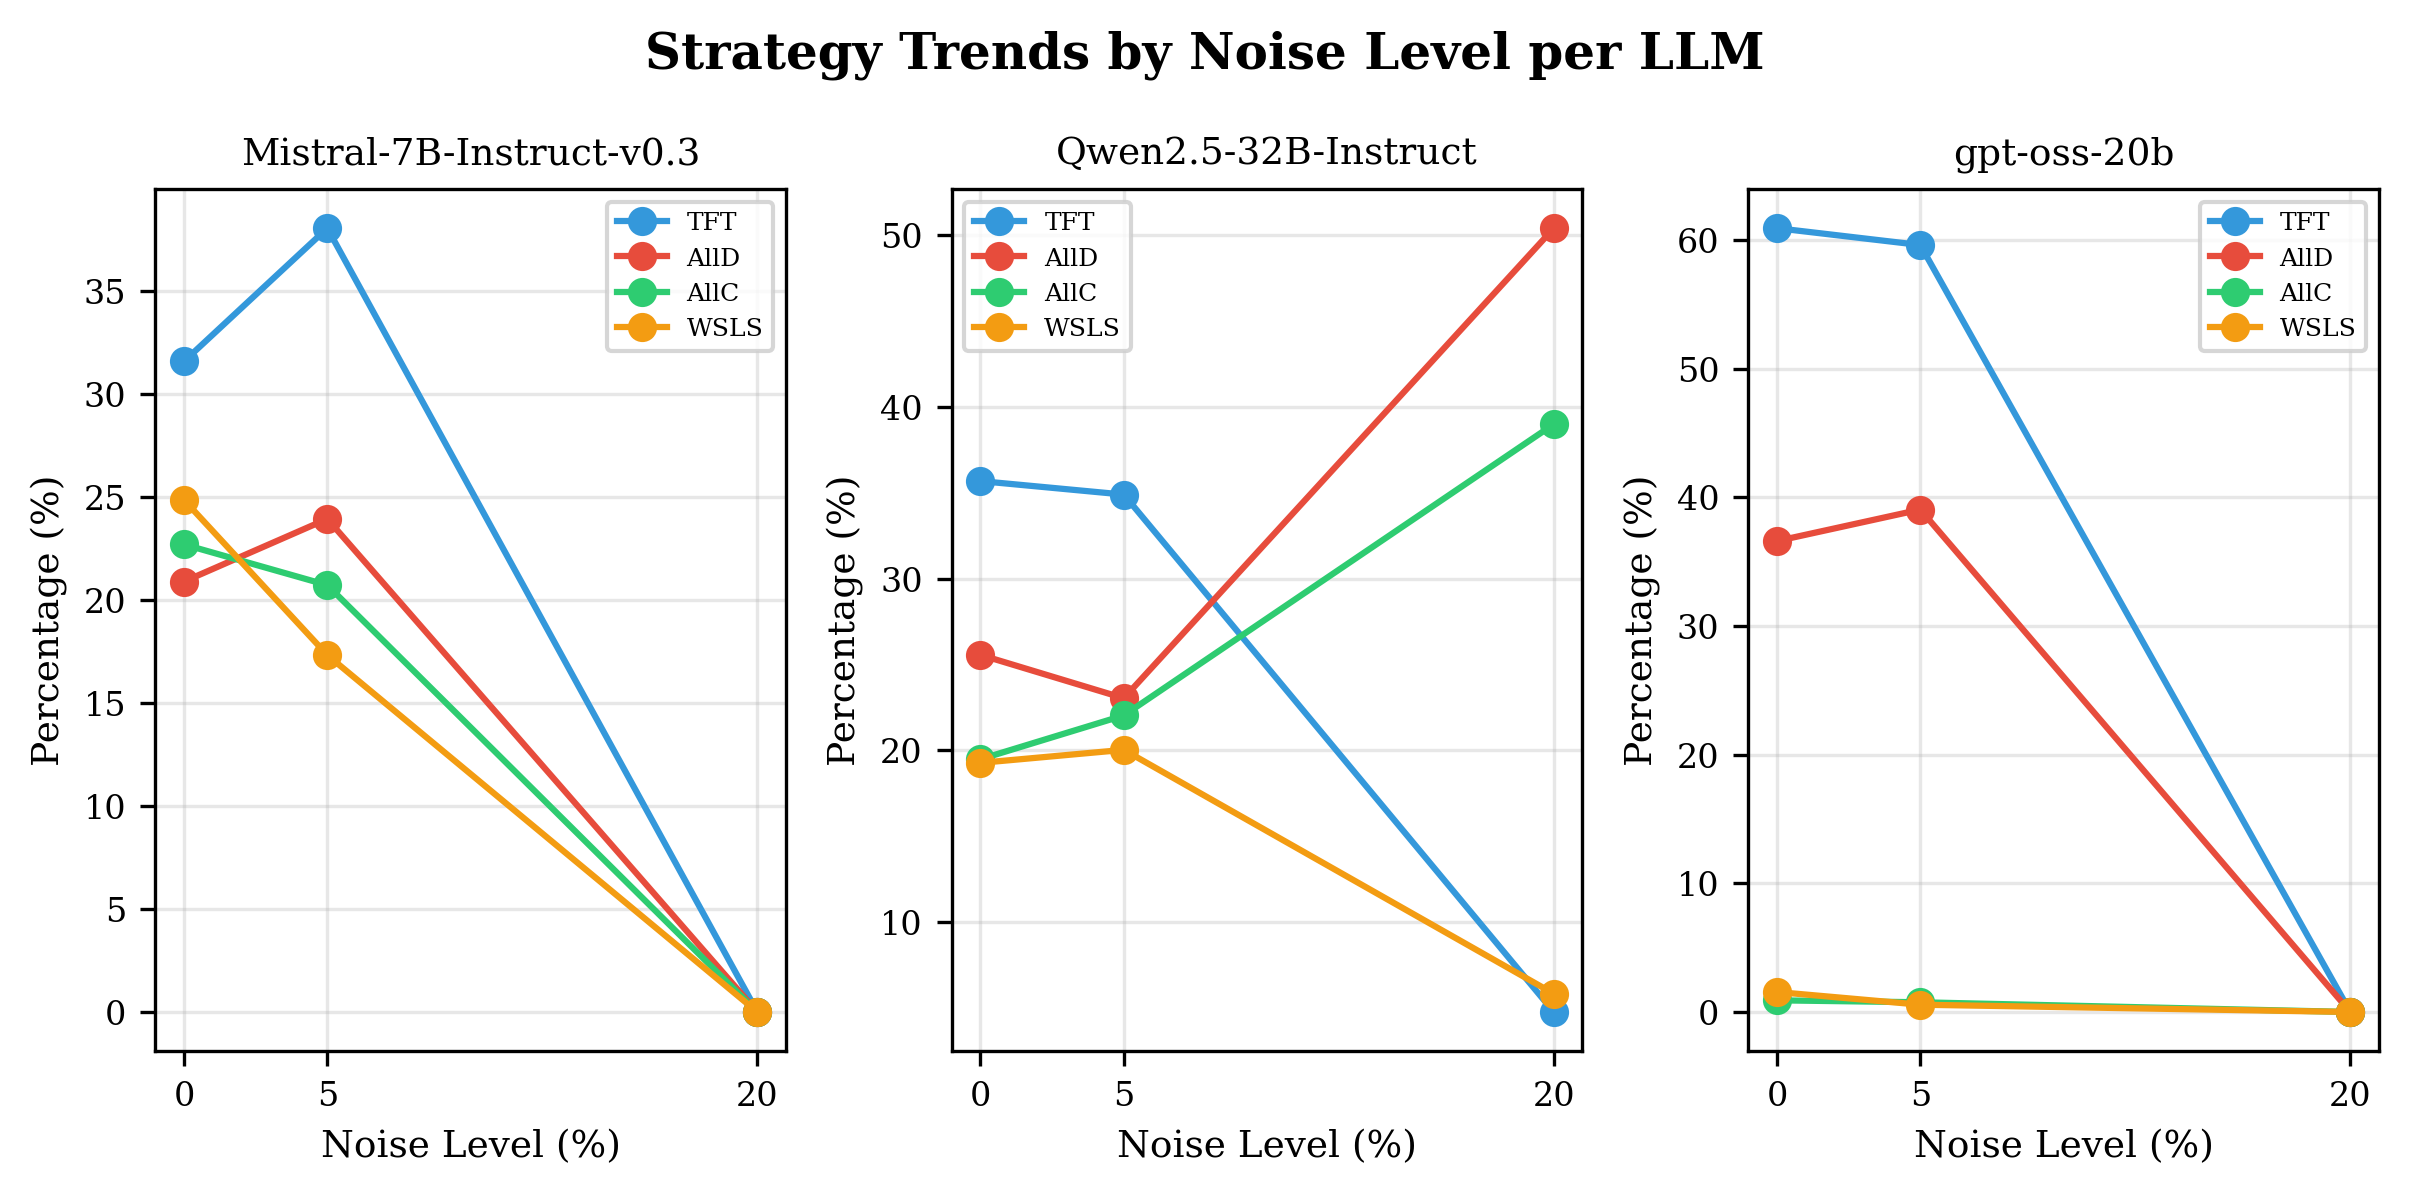

In [30]:
# ============================================================================
# Cell 23: Fig 8 - Noise × LLM Interaction (Strategy Trends)
# ============================================================================

llm_names = df_all['llm_name'].unique()
n_models = len(llm_names)
n_cols = min(n_models, 3)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(DOUBLE_COL * 1.2, 4 * n_rows))
if n_models == 1:
    axes = np.array([axes])
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for ax_idx, llm in enumerate(llm_names):
    ax = axes[ax_idx]
    llm_data = df_all[df_all['llm_name'] == llm]
    
    for strat in strategies_order:
        pcts = []
        for noise in noise_levels:
            subset = llm_data[llm_data['noise_level'] == noise]
            total = len(subset)
            count = len(subset[subset['predicted_strategy'] == strat])
            pcts.append(count / total * 100 if total > 0 else 0)
        
        color = STRATEGY_COLORS.get(strat, '#95a5a6')
        ax.plot(noise_levels, pcts, 'o-', label=strat, color=color, linewidth=1.5, markersize=6)
    
    ax.set_xlabel('Noise Level (%)')
    ax.set_ylabel('Percentage (%)')
    ax.set_title(llm, fontsize=9)
    ax.set_xticks(noise_levels)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6)

# Hide unused axes
for i in range(n_models, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Strategy Trends by Noise Level per LLM', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig8_noise_llm_interaction.png', dpi=DPI)
plt.savefig(FIGURES_DIR / 'fig8_noise_llm_interaction.pdf')
plt.show()

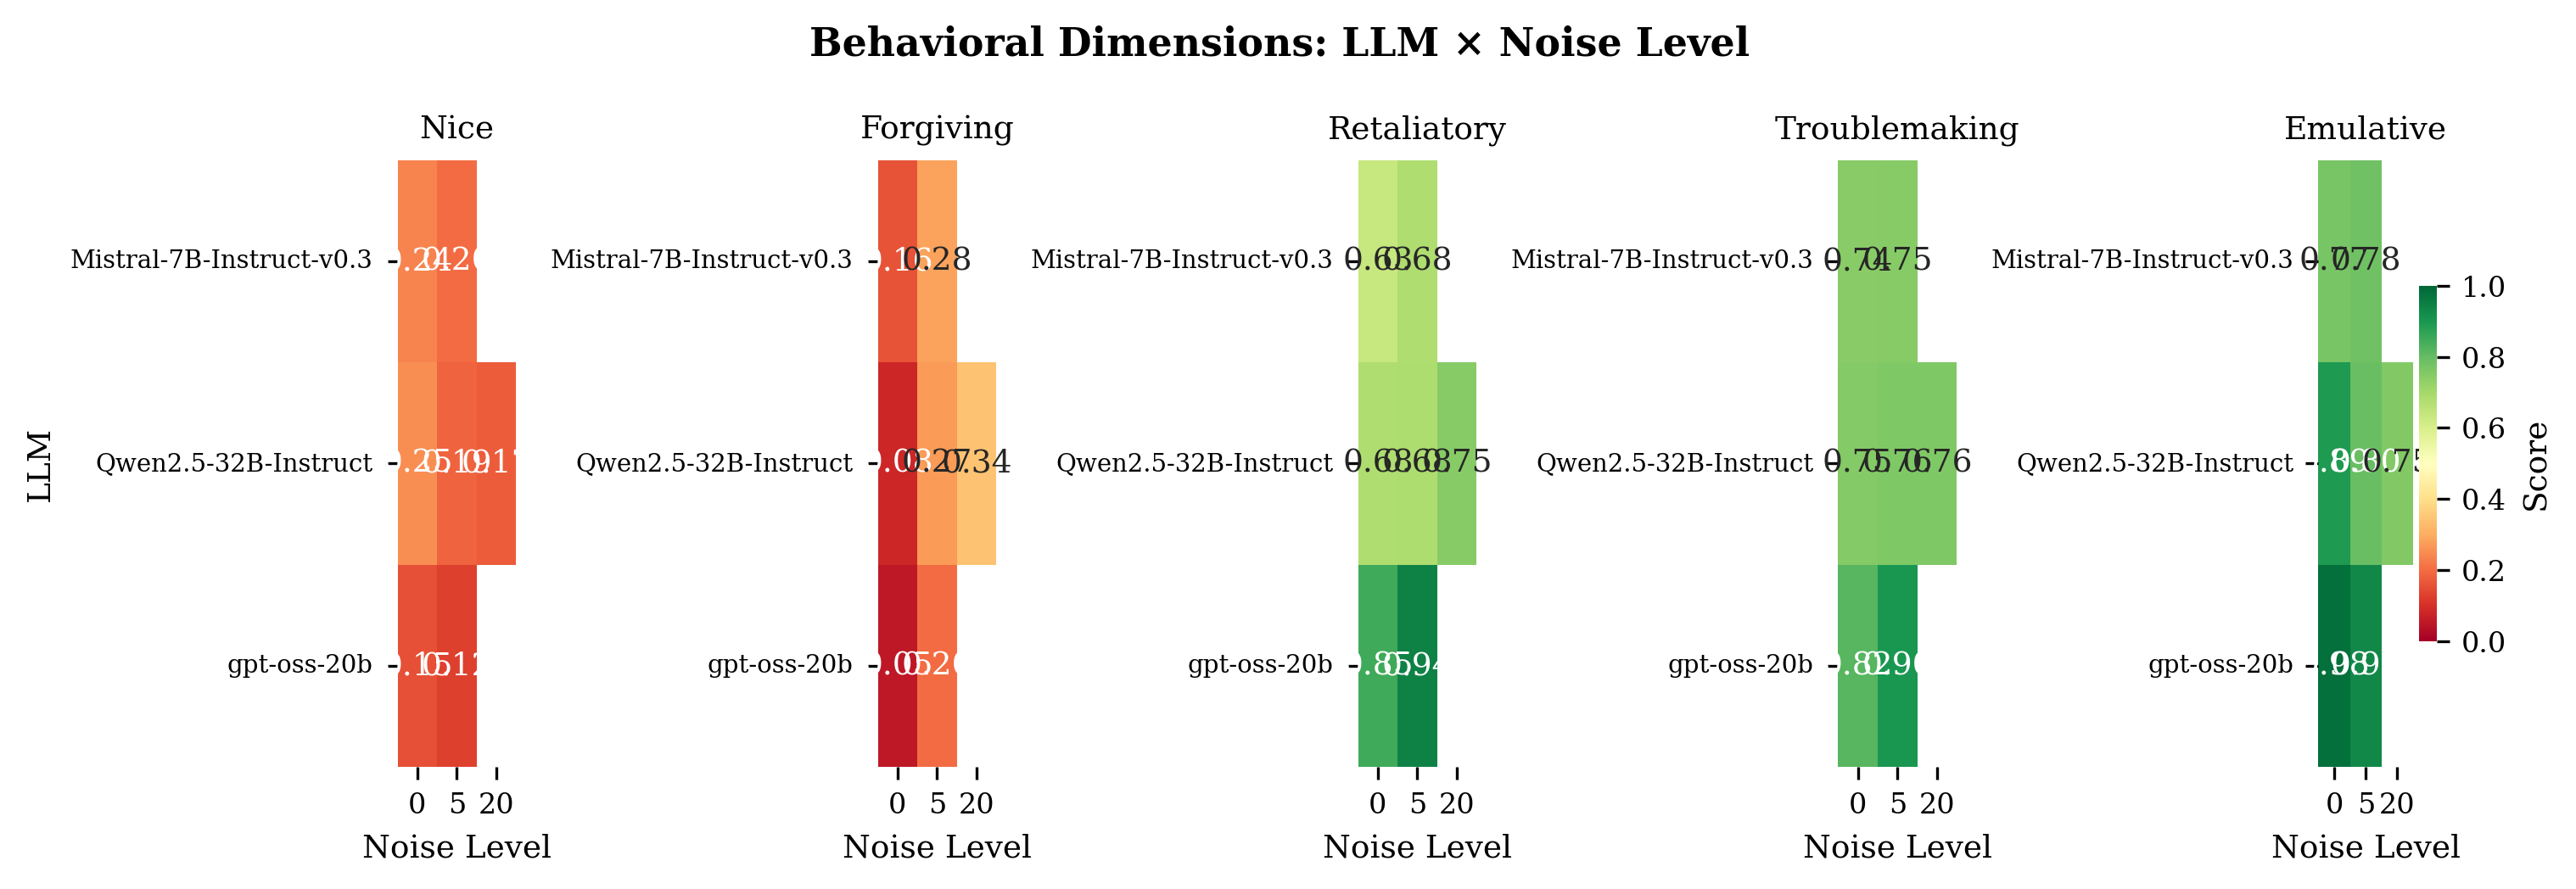

In [31]:
# ============================================================================
# Cell 24: Fig 9 - Behavioral Profile Heatmap by LLM × Noise
# ============================================================================

fig, axes = plt.subplots(1, len(dim_cols), figsize=(DOUBLE_COL * 1.5, 3.5))

for i, dim in enumerate(dim_cols):
    pivot = df_profiles.pivot_table(
        values=dim, index='llm_name', columns='noise_level', aggfunc='mean'
    )
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[i],
                vmin=0, vmax=1, cbar=i == len(dim_cols)-1,
                cbar_kws={'label': 'Score'} if i == len(dim_cols)-1 else {})
    axes[i].set_title(dim.capitalize(), fontsize=9)
    axes[i].set_ylabel('' if i > 0 else 'LLM')
    axes[i].set_xlabel('Noise Level')
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0, fontsize=7)

plt.suptitle('Behavioral Dimensions: LLM × Noise Level', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig9_behavioral_heatmap.png', dpi=DPI, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'fig9_behavioral_heatmap.pdf', bbox_inches='tight')
plt.show()

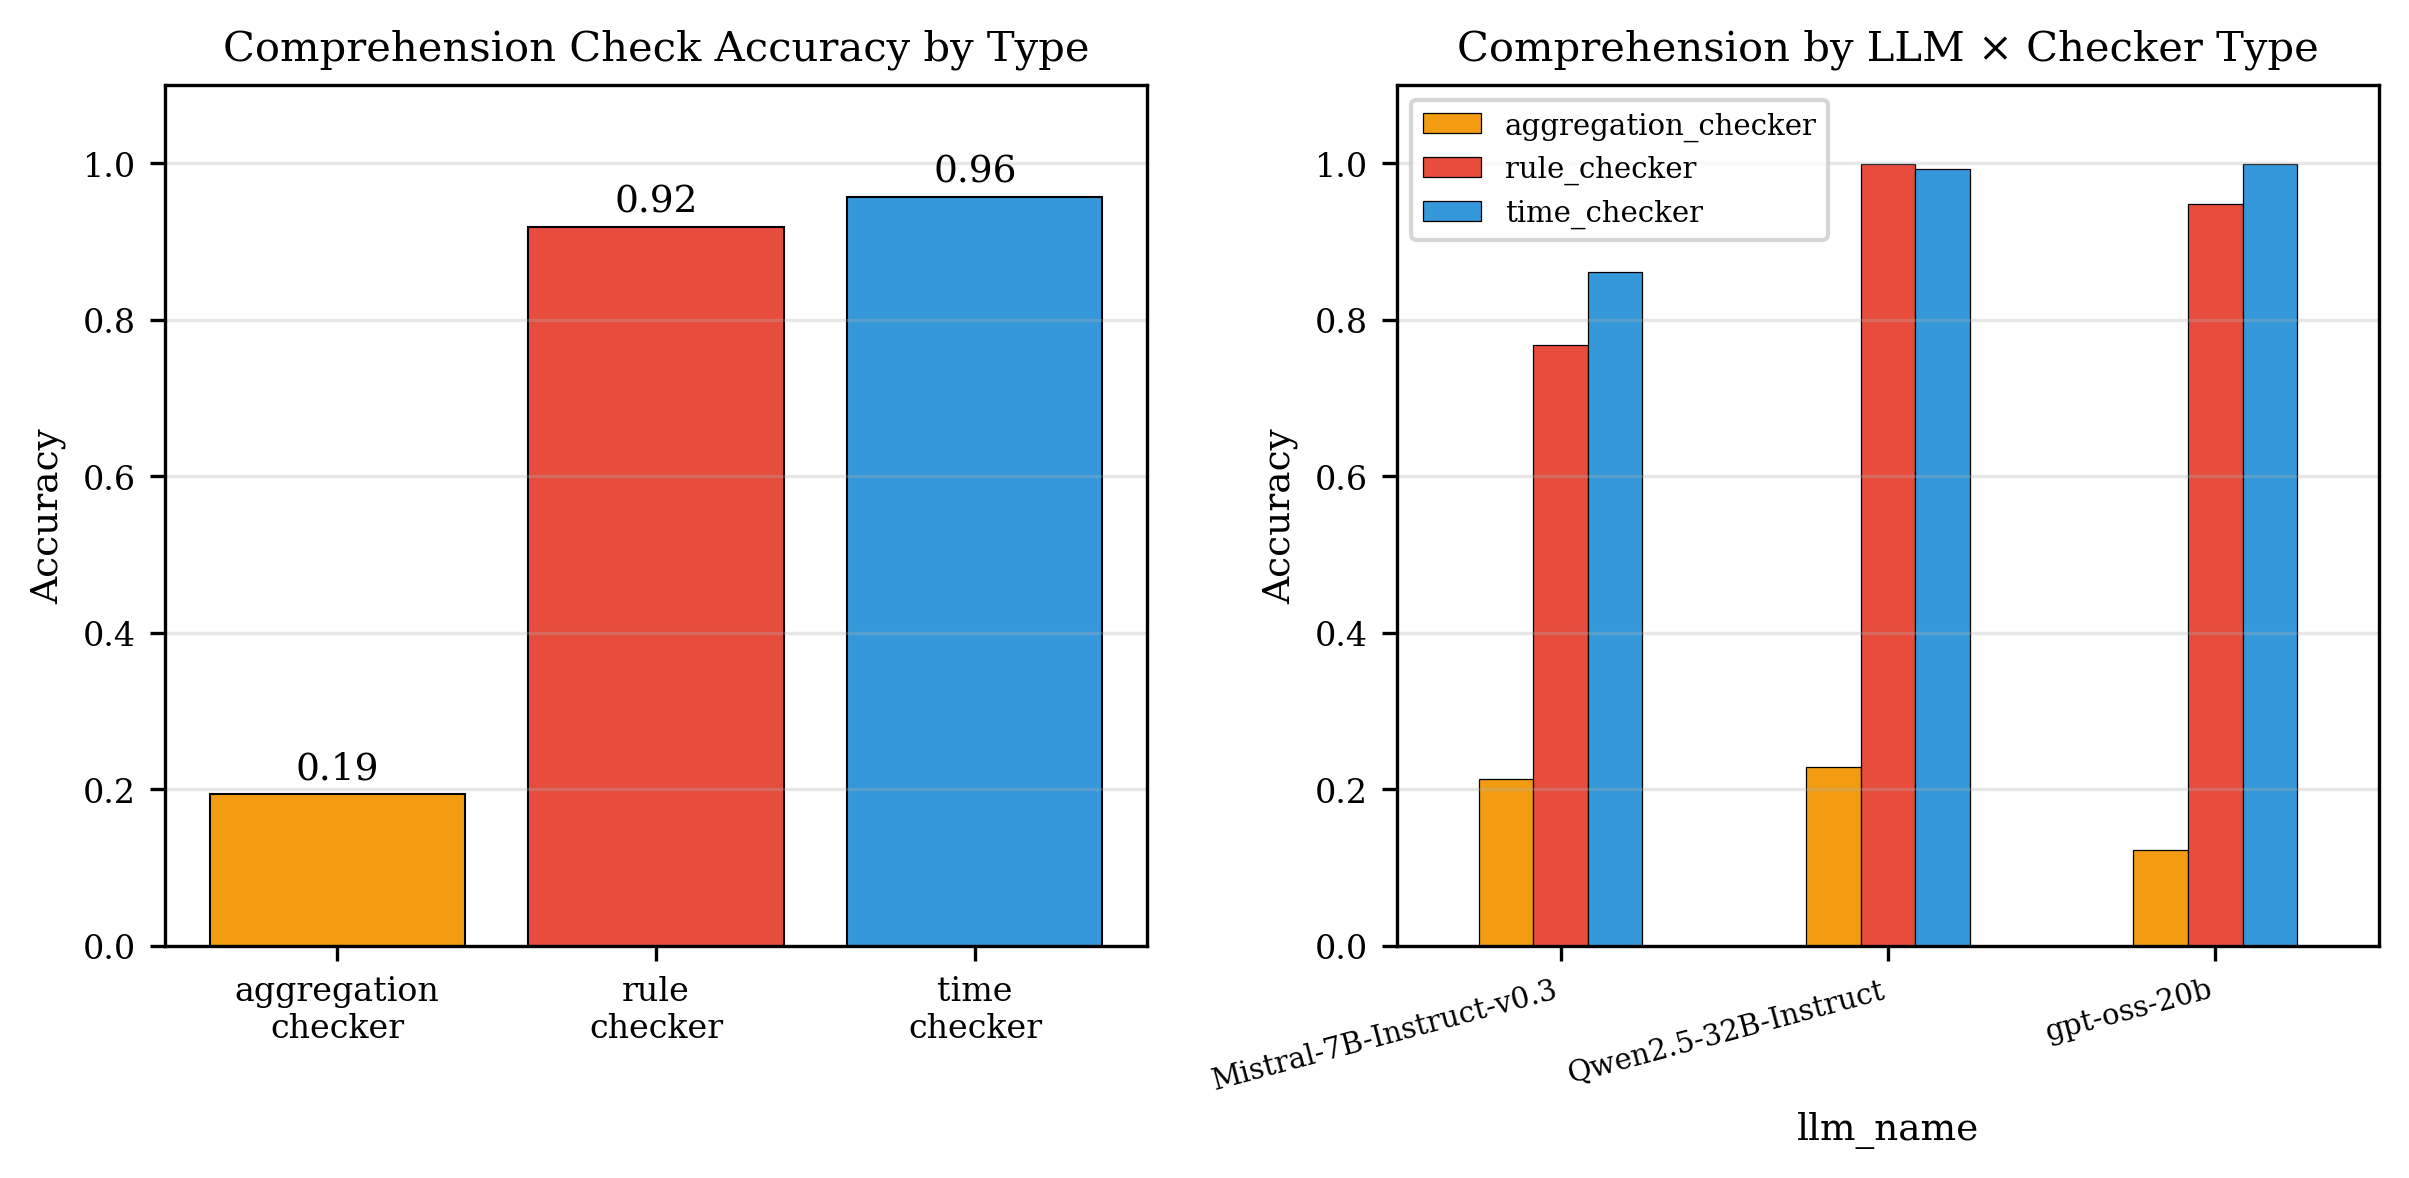

In [32]:
# ============================================================================
# Cell 25: Fig 10 - Comprehension Question Analysis
# ============================================================================

if 'checker_name' in df_checkers.columns:
    fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL * 1.2, 4))
    
    # Accuracy by checker type
    ax = axes[0]
    checker_acc = df_checkers.groupby('checker_name')['is_correct'].mean()
    checker_colors = {'time_checker': '#3498db', 'rule_checker': '#e74c3c', 'aggregation_checker': '#f39c12'}
    colors = [checker_colors.get(c, '#333') for c in checker_acc.index]
    bars = ax.bar(checker_acc.index, checker_acc.values, color=colors, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, checker_acc.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('Accuracy')
    ax.set_title('Comprehension Check Accuracy by Type')
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels([c.replace('_', '\n') for c in checker_acc.index], fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    
    # Accuracy by LLM
    ax = axes[1]
    checker_by_llm = df_checkers.groupby(['llm_name', 'checker_name'])['is_correct'].mean().unstack(fill_value=0)
    checker_by_llm.plot(kind='bar', ax=ax, color=[checker_colors.get(c, '#333') for c in checker_by_llm.columns],
                        edgecolor='black', linewidth=0.3)
    ax.set_ylabel('Accuracy')
    ax.set_title('Comprehension by LLM × Checker Type')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=7)
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig10_comprehension_analysis.png', dpi=DPI)
    plt.savefig(FIGURES_DIR / 'fig10_comprehension_analysis.pdf')
    plt.show()
else:
    print('Checker data columns:', df_checkers.columns.tolist())

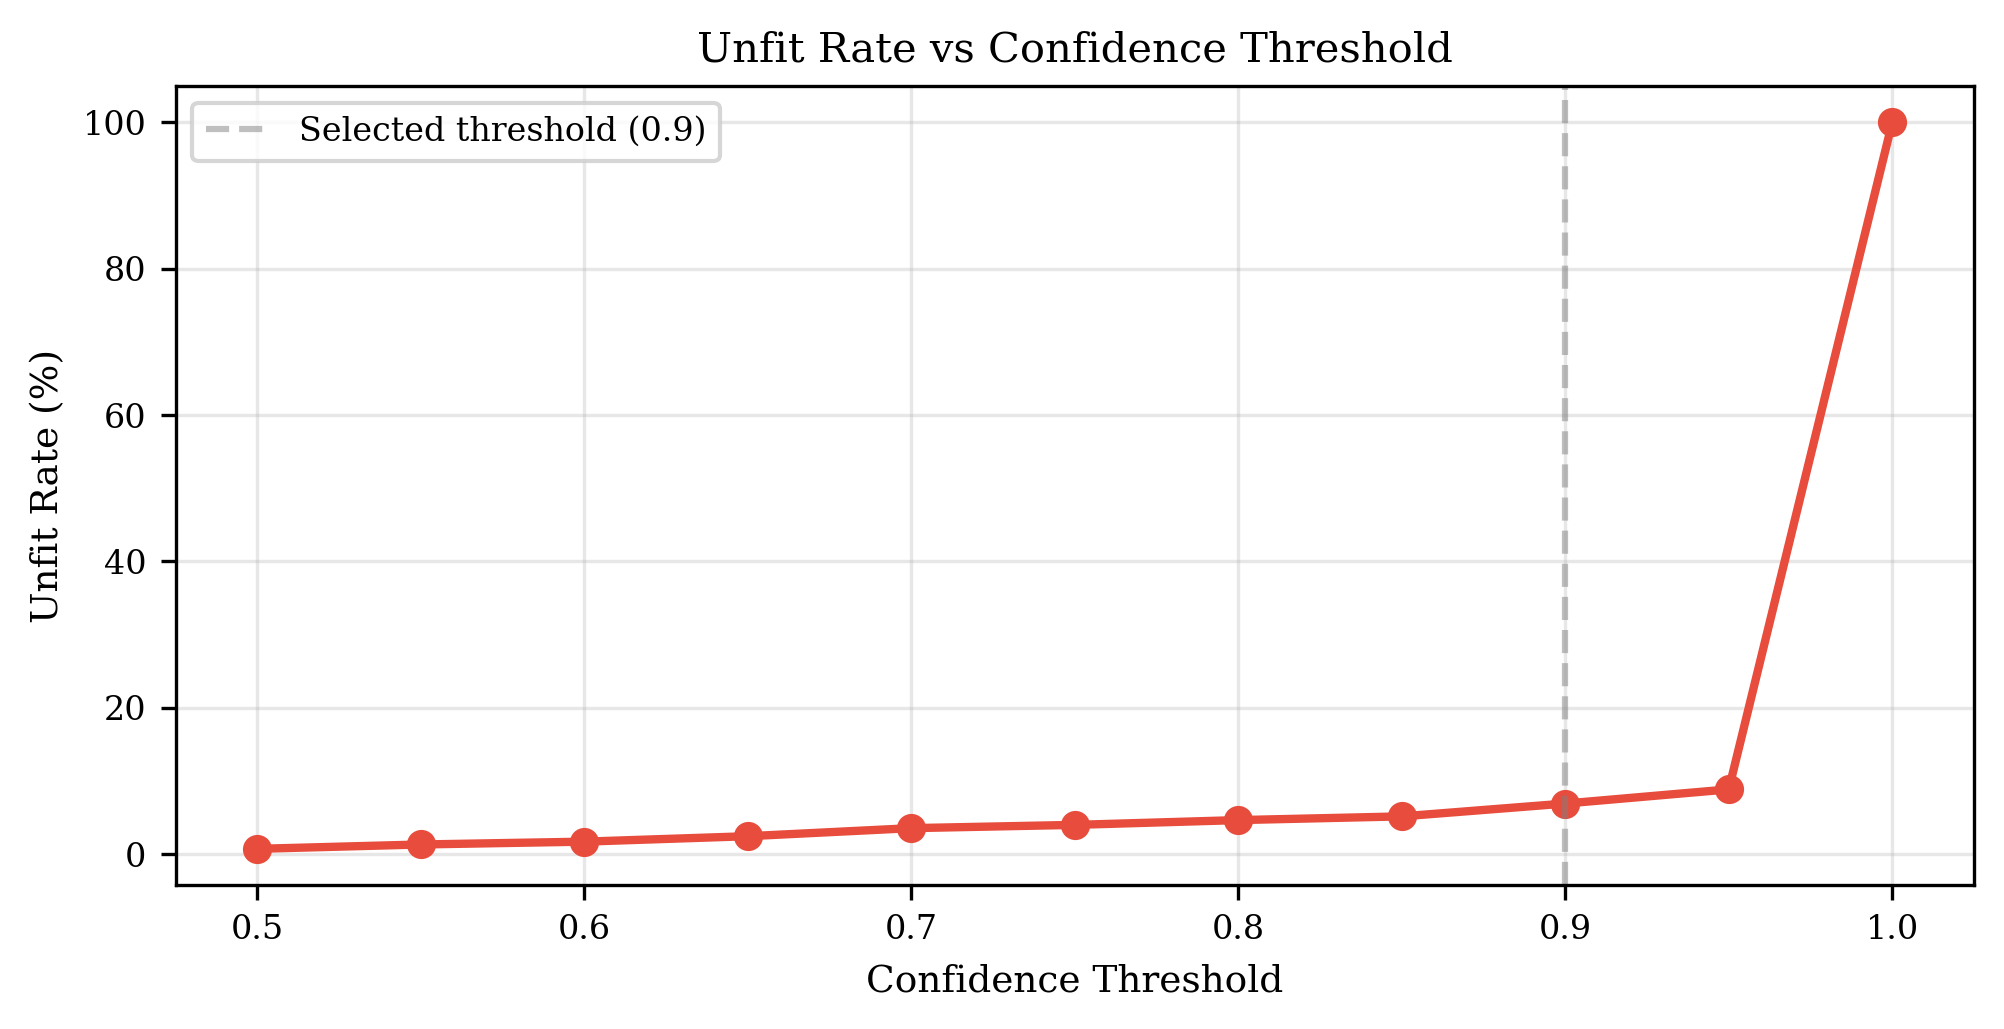

Unfit rate at threshold 0.9: 232/3360 = 6.9%


In [33]:
# ============================================================================
# Cell 26: Fig 11 - Unfit Rate vs Confidence Threshold
# ============================================================================

thresholds = np.arange(0.5, 1.01, 0.05)
unfit_rates = []

for thr in thresholds:
    n_unfit = len(agent_df[agent_df['prediction_confidence'] < thr])
    unfit_rates.append(n_unfit / len(agent_df) * 100)

fig, ax = plt.subplots(figsize=(DOUBLE_COL, 3.5))
ax.plot(thresholds, unfit_rates, 'o-', color='#e74c3c', linewidth=2, markersize=6)
ax.axvline(x=CONFIDENCE_THRESHOLD, color='gray', linestyle='--', alpha=0.5,
           label=f'Selected threshold ({CONFIDENCE_THRESHOLD})')
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('Unfit Rate (%)')
ax.set_title('Unfit Rate vs Confidence Threshold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig11_unfit_rate_vs_threshold.png', dpi=DPI)
plt.savefig(FIGURES_DIR / 'fig11_unfit_rate_vs_threshold.pdf')
plt.show()

# Print unfit rate at selected threshold
n_unfit = len(agent_df[agent_df['prediction_confidence'] < CONFIDENCE_THRESHOLD])
print(f'Unfit rate at threshold {CONFIDENCE_THRESHOLD}: {n_unfit}/{len(agent_df)} = {n_unfit/len(agent_df)*100:.1f}%')

---
## Part VII: Statistical Analysis

In [ ]:
# ============================================================================
# Cell 27: Statistical Tests
# ============================================================================

print('=' * 70)
print('STATISTICAL ANALYSIS')
print('=' * 70)

# 1. Kruskal-Wallis: Cooperation rate differences across LLMs
print('\n--- 1. Kruskal-Wallis: Cooperation Rate by LLM ---')
groups = [group['cooperation_rate'].values for _, group in agent_df.groupby('llm_name')]
if len(groups) >= 2:
    stat, p = kruskal(*groups)
    print(f'  H-statistic: {stat:.4f}, p-value: {p:.6f}')
    print(f'  {"Significant" if p < 0.05 else "Not significant"} at alpha=0.05')

# 2. Mann-Whitney U: Cooperative vs Selfish personality
print('\n--- 2. Mann-Whitney U: Cooperative vs Selfish Personality ---')
coop_rates_coop = agent_df[agent_df['personality'] == 'cooperative']['cooperation_rate'].values
coop_rates_self = agent_df[agent_df['personality'] == 'selfish']['cooperation_rate'].values
if len(coop_rates_coop) > 0 and len(coop_rates_self) > 0:
    stat, p = mannwhitneyu(coop_rates_coop, coop_rates_self, alternative='two-sided')
    print(f'  U-statistic: {stat:.4f}, p-value: {p:.6f}')
    print(f'  Cooperative mean: {np.mean(coop_rates_coop):.4f}, Selfish mean: {np.mean(coop_rates_self):.4f}')
    print(f'  {"Significant" if p < 0.05 else "Not significant"} at alpha=0.05')

# 3. Kruskal-Wallis: Effect of noise on cooperation
print('\n--- 3. Kruskal-Wallis: Effect of Noise on Cooperation ---')
noise_groups = [group['cooperation_rate'].values for _, group in agent_df.groupby('noise_level')]
if len(noise_groups) >= 2:
    stat, p = kruskal(*noise_groups)
    print(f'  H-statistic: {stat:.4f}, p-value: {p:.6f}')
    print(f'  {"Significant" if p < 0.05 else "Not significant"} at alpha=0.05')

# 4. Spearman correlation: behavioral dimensions
print('\n--- 4. Spearman Correlations: Behavioral Dimensions ---')
for i, dim1 in enumerate(dims):
    for dim2 in dims[i+1:]:
        rho, p = spearmanr(df_profiles[dim1], df_profiles[dim2])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        if abs(rho) > 0.3:  # Only show moderate+ correlations
            print(f'  {dim1} vs {dim2}: rho={rho:.3f}, p={p:.4f} {sig}')

# 5. Cooperation rate summary statistics
print('\n--- 5. Cooperation Rate Summary ---')
for llm in agent_df['llm_name'].unique():
    llm_data = agent_df[agent_df['llm_name'] == llm]['cooperation_rate']
    ci = st.t.interval(0.95, len(llm_data)-1, loc=llm_data.mean(), scale=st.sem(llm_data))
    print(f'  {llm}: mean={llm_data.mean():.4f} (95% CI: [{ci[0]:.4f}, {ci[1]:.4f}])')

STATISTICAL ANALYSIS

--- 1. Kruskal-Wallis: Cooperation Rate by LLM ---
  H-statistic: 523.7264, p-value: 0.000000
  Significant at alpha=0.05

--- 2. Mann-Whitney U: Cooperative vs Selfish Personality ---
  U-statistic: 66010.0000, p-value: 0.000000
  Cooperative mean: 0.5775, Selfish mean: 0.0499
  Significant at alpha=0.05

--- 3. Kruskal-Wallis: Effect of Noise on Cooperation ---
  H-statistic: 206.7166, p-value: 0.000000
  Significant at alpha=0.05

--- 4. Spearman Correlations: Behavioral Dimensions ---
  nice vs forgiving: rho=0.519, p=0.0000 ***
  nice vs retaliatory: rho=-0.469, p=0.0000 ***
  nice vs troublemaking: rho=-0.812, p=0.0000 ***
  nice vs emulative: rho=-0.370, p=0.0000 ***
  forgiving vs retaliatory: rho=-0.470, p=0.0000 ***
  forgiving vs troublemaking: rho=-0.673, p=0.0000 ***
  forgiving vs emulative: rho=-0.781, p=0.0000 ***
  retaliatory vs troublemaking: rho=0.635, p=0.0000 ***
  retaliatory vs emulative: rho=0.682, p=0.0000 ***
  troublemaking vs emulative

In [35]:
# ============================================================================
# Cell 28: Pairwise Mann-Whitney U Tests for LLMs
# ============================================================================

print('--- Pairwise Mann-Whitney U Tests: Cooperation Rate ---')
llm_list = df_profiles['llm_name'].unique()

results_pairs = []
for i in range(len(llm_list)):
    for j in range(i+1, len(llm_list)):
        g1 = df_profiles[df_profiles['llm_name'] == llm_list[i]]['cooperation_rate'].values
        g2 = df_profiles[df_profiles['llm_name'] == llm_list[j]]['cooperation_rate'].values
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        results_pairs.append({
            'LLM 1': llm_list[i], 'LLM 2': llm_list[j],
            'U-stat': stat, 'p-value': p,
            'Significant': 'Yes' if p < 0.05 else 'No',
            'Mean 1': np.mean(g1), 'Mean 2': np.mean(g2)
        })

df_pairwise = pd.DataFrame(results_pairs)
print(df_pairwise.to_string(index=False))

# Also test behavioral dimensions across LLMs
print('\n--- Kruskal-Wallis for Behavioral Dimensions across LLMs ---')
for dim in dims:
    groups = [group[dim].values for _, group in df_profiles.groupby('llm_name')]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f'  {dim:15s}: H={stat:8.3f}, p={p:.6f} {sig}')

--- Pairwise Mann-Whitney U Tests: Cooperation Rate ---
                   LLM 1                LLM 2    U-stat       p-value Significant   Mean 1   Mean 2
Mistral-7B-Instruct-v0.3 Qwen2.5-32B-Instruct  721979.5  6.226247e-02          No 0.491979 0.448935
Mistral-7B-Instruct-v0.3          gpt-oss-20b  684148.0  5.310800e-78         Yes 0.491979 0.073504
    Qwen2.5-32B-Instruct          gpt-oss-20b 1042304.5 1.847474e-101         Yes 0.448935 0.073504

--- Kruskal-Wallis for Behavioral Dimensions across LLMs ---
  nice           : H=  21.556, p=0.000021 ***
  forgiving      : H=  32.295, p=0.000000 ***
  retaliatory    : H= 164.096, p=0.000000 ***
  troublemaking  : H=  68.810, p=0.000000 ***
  emulative      : H=  42.584, p=0.000000 ***


---
## Part VIII: 3-Player Analysis

In [36]:
# ============================================================================
# Cell 29: Load & Analyze 3-Player Data
# ============================================================================

# Scan for 3-player game data
print('Scanning 3-player results...')

games_3p_files = []
rounds_3p_files = []

for model_dir in RESULTS_3P.iterdir():
    if model_dir.is_dir():
        for noise_dir in model_dir.iterdir():
            if noise_dir.is_dir():
                gs = noise_dir / 'games_summary.csv'
                rd = noise_dir / 'rounds_detail.csv'
                if gs.exists():
                    games_3p_files.append(gs)
                if rd.exists():
                    rounds_3p_files.append(rd)

if games_3p_files:
    df_games_3p = pd.concat([pd.read_csv(f) for f in games_3p_files], ignore_index=True)
    print(f'3-Player games loaded: {len(df_games_3p)} games')
    print(f'Columns: {df_games_3p.columns.tolist()}')
    
    # Cooperation rates
    for agent_num in [1, 2, 3]:
        col = f'agent{agent_num}_cooperation_rate'
        if col in df_games_3p.columns:
            print(f'  Agent{agent_num} mean cooperation: {df_games_3p[col].mean():.4f}')
else:
    df_games_3p = pd.DataFrame()
    print('No 3-player game data found.')

Scanning 3-player results...
3-Player games loaded: 269 games
Columns: ['game_id', 'run_id', 'timestamp', 'language', 'n_rounds_known', 'max_rounds', 'played_rounds', 'agent1_name', 'agent1_llm', 'agent1_personality', 'agent1_noise_rate', 'agent1_total_score', 'agent1_cooperation_rate', 'agent1_defection_rate', 'agent1_flipped_count', 'agent1_flipped_rounds', 'agent1_strategies', 'agent1_intended_strategies', 'agent2_name', 'agent2_llm', 'agent2_personality', 'agent2_noise_rate', 'agent2_total_score', 'agent2_cooperation_rate', 'agent2_defection_rate', 'agent2_flipped_count', 'agent2_flipped_rounds', 'agent2_strategies', 'agent2_intended_strategies', 'agent3_name', 'agent3_llm', 'agent3_personality', 'agent3_noise_rate', 'agent3_total_score', 'agent3_cooperation_rate', 'agent3_defection_rate', 'agent3_flipped_count', 'agent3_flipped_rounds', 'agent3_strategies', 'agent3_intended_strategies', 'time_checker_accuracy', 'rule_checker_accuracy', 'aggregation_checker_accuracy']
  Agent1 mean

In [45]:
# ============================================================================
# Cell 30: 3-Player Strategy Detection & Behavioral Analysis
# ============================================================================

if len(df_games_3p) > 0:
    # For 3-player: analyze agent pairwise against average opponent
    # Strategy detection: treat the majority opponent action as the opponent's action
    
    agent_3p_rows = []
    
    for idx, row in df_games_3p.iterrows():
        for agent_num in [1, 2, 3]:
            agent_prefix = f'agent{agent_num}'
            my_strats = parse_strategy_string(row.get(f'{agent_prefix}_strategies', ''))
            
            if len(my_strats) == 0:
                continue
            
            # Get opponent strategies (average of other 2 agents)
            opp_nums = [n for n in [1, 2, 3] if n != agent_num]
            opp_strats_all = []
            for opp_num in opp_nums:
                opp_s = parse_strategy_string(row.get(f'agent{opp_num}_strategies', ''))
                if opp_s:
                    opp_strats_all.append(opp_s)
            
            if not opp_strats_all:
                continue
            
            # Majority opponent action per round
            min_len = min(len(my_strats), min(len(os) for os in opp_strats_all))
            my_strats = my_strats[:min_len]
            
            majority_opp = []
            for r in range(min_len):
                opp_actions = [os[r] for os in opp_strats_all if r < len(os)]
                c_count = sum(1 for a in opp_actions if normalize_action(a) == 'C')
                majority_opp.append('C' if c_count > len(opp_actions) / 2 else 'D')
            
            # State-action encoding
            sa_seq = get_state_action_sequence(my_strats, majority_opp)
            
            # Behavioral profile
            main_hist = [1 if normalize_action(s) == 'C' else 0 for s in my_strats]
            opp_hist = [1 if s == 'C' else 0 for s in majority_opp]  # majority_opp already normalized
            
            agent_3p_rows.append({
                'game_id': row.get('game_id', f'3p_game_{idx}'),
                'agent_name': f'agent{agent_num}',
                'personality': row.get(f'{agent_prefix}_personality', 'unknown'),
                'cooperation_rate': row.get(f'{agent_prefix}_cooperation_rate', np.nan),
                'state_action_seq': sa_seq,
                'nice': compute_niceness(main_hist, opp_hist),
                'forgiving': compute_forgiveness(main_hist, opp_hist),
                'retaliatory': compute_retaliation(main_hist, opp_hist),
                'troublemaking': compute_troublemaking(main_hist, opp_hist),
                'emulative': compute_emulation(main_hist, opp_hist),
            })
    
    df_agents_3p = pd.DataFrame(agent_3p_rows)
    
    # LSTM predictions for 3-player
    if len(df_agents_3p) > 0 and '4strat' in models:
        sa_seqs = df_agents_3p['state_action_seq'].tolist()
        lstm_model = models[SELECTED_MODEL]
        results_3p = predict_lstm_batch(sa_seqs, lstm_model, label_encoder)
        df_agents_3p['predicted_strategy'] = [r[0] for r in results_3p]
        df_agents_3p['prediction_confidence'] = [r[1] for r in results_3p]
        
        # Rule-based override
        for i, sa_seq in enumerate(sa_seqs):
            if sa_seq:
                tokens = sa_seq.strip().split()
                rule_strats, rule_conf = detect_strategy_by_rules(tokens)
                if rule_strats:
                    df_agents_3p.loc[i, 'predicted_strategy'] = '|'.join(rule_strats)
                    df_agents_3p.loc[i, 'prediction_confidence'] = rule_conf
        
        print(f'3-Player agents analyzed: {len(df_agents_3p)}')
        print(f'\nStrategy distribution (3-player):')
        print(df_agents_3p['predicted_strategy'].value_counts())
        print(f'\nBehavioral profile (3-player):')
        print(df_agents_3p[dims].mean().round(3))
    else:
        print('No agents to analyze for 3-player.')
else:
    df_agents_3p = pd.DataFrame()
    print('No 3-player data available.')

3-Player agents analyzed: 807

Strategy distribution (3-player):
predicted_strategy
AllD    369
AllC    189
TFT     164
WSLS     85
Name: count, dtype: int64

Behavioral profile (3-player):
nice             0.425
forgiving        0.772
retaliatory      0.670
troublemaking    0.585
emulative        0.655
dtype: float64


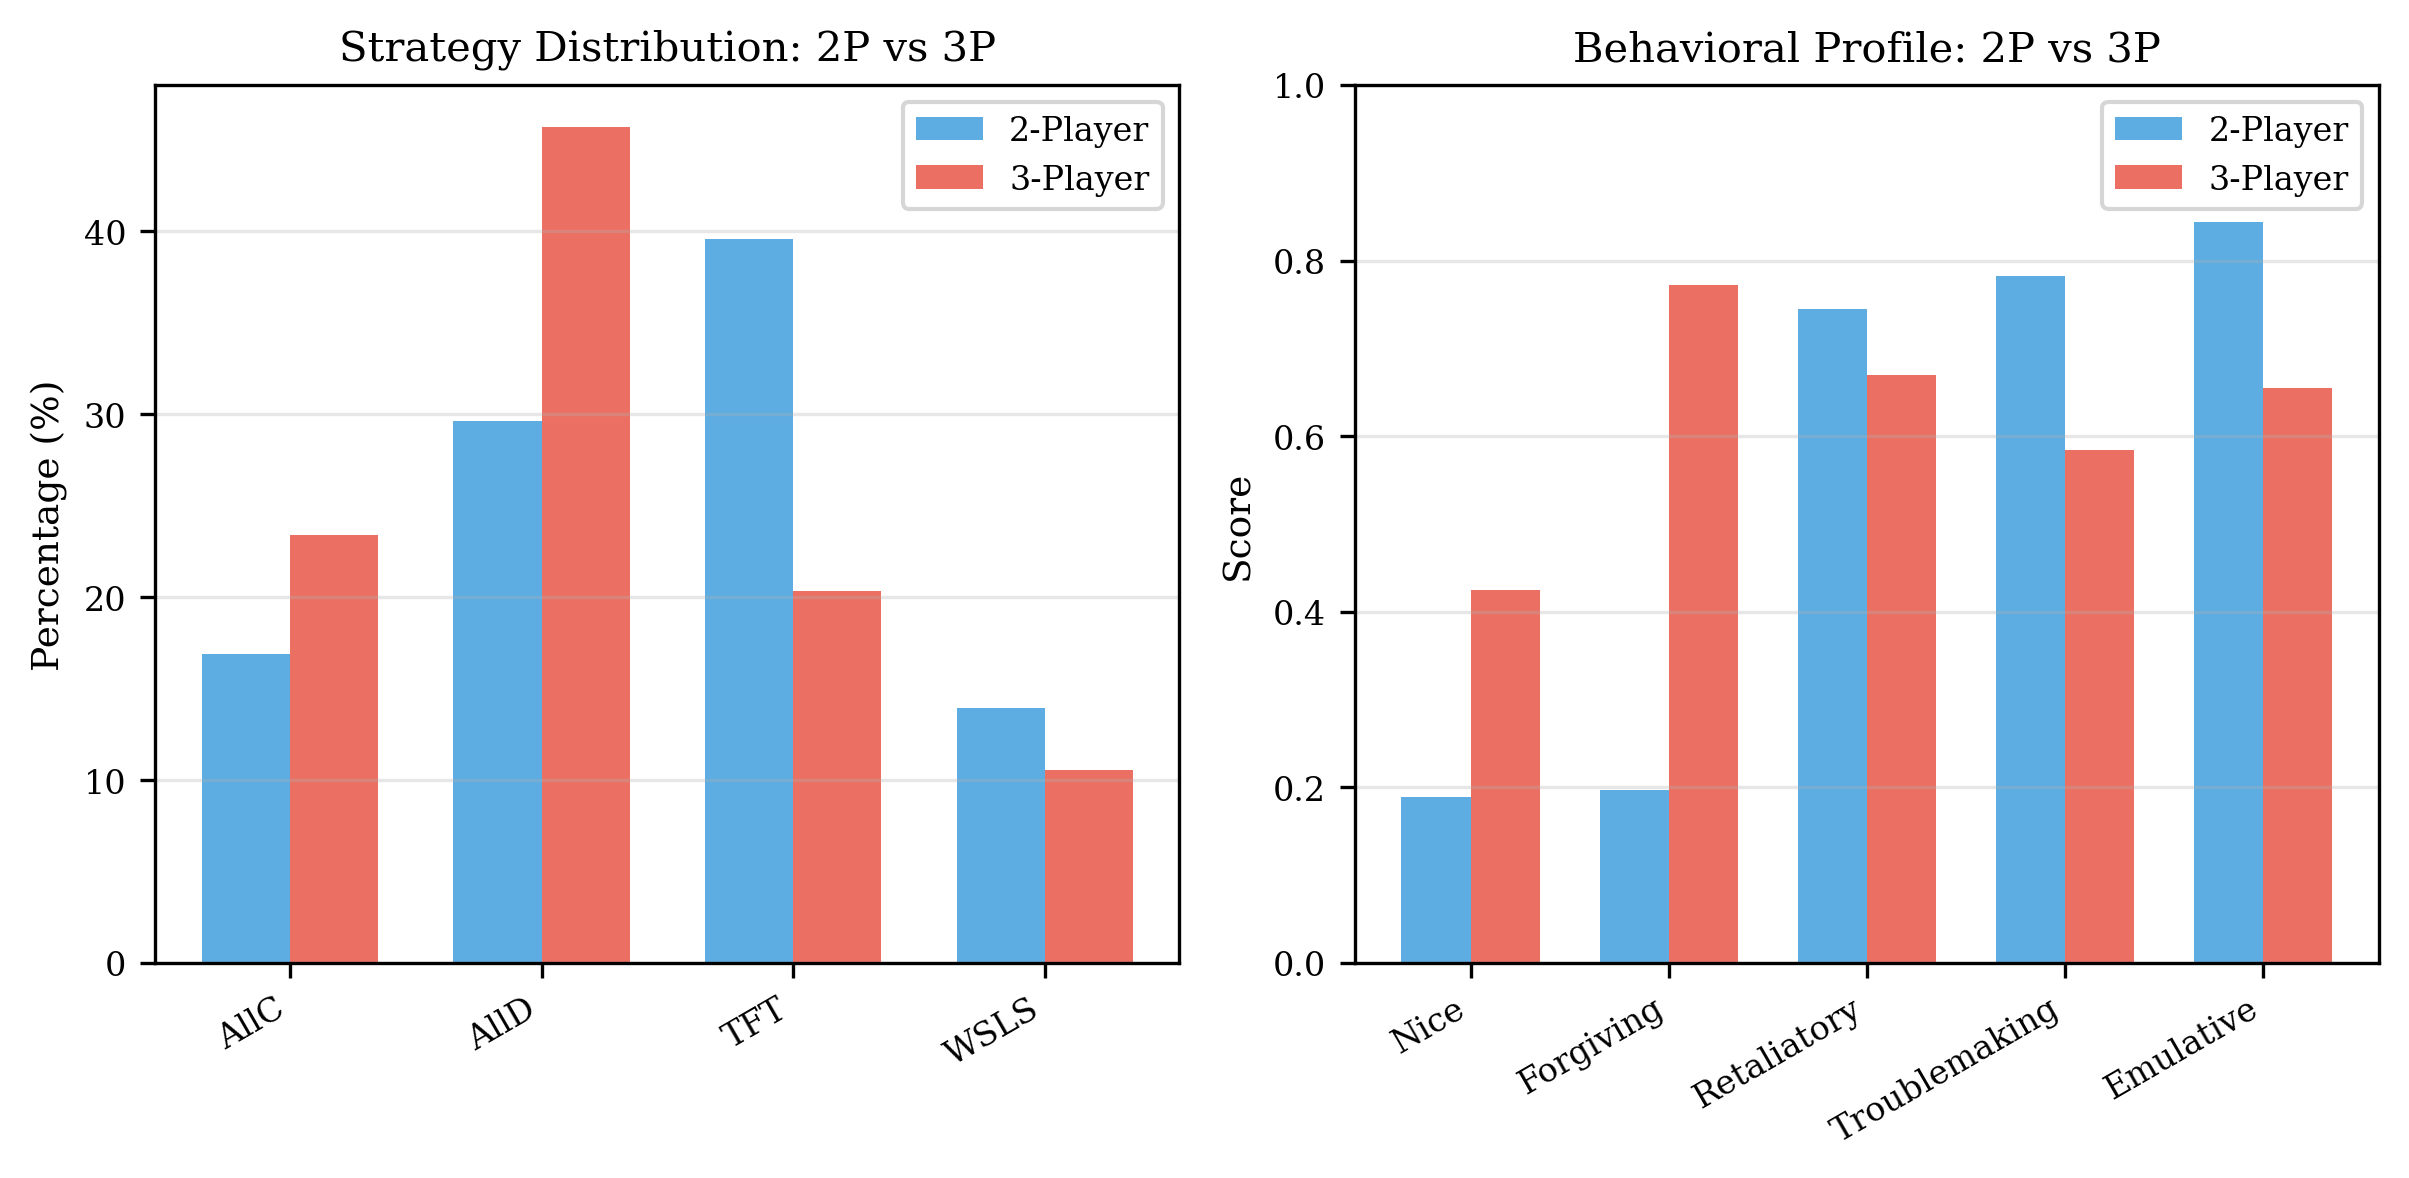

In [39]:
# ============================================================================
# Cell 31: 2P vs 3P Comparison Visualization
# ============================================================================

if len(df_agents_3p) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL * 1.2, 4))
    
    # Strategy comparison
    ax = axes[0]
    strat_2p = df_all['predicted_strategy'].value_counts(normalize=True) * 100
    strat_3p = df_agents_3p['predicted_strategy'].value_counts(normalize=True) * 100
    
    all_strats = sorted(set(strat_2p.index) | set(strat_3p.index))
    x = np.arange(len(all_strats))
    width = 0.35
    
    vals_2p = [strat_2p.get(s, 0) for s in all_strats]
    vals_3p = [strat_3p.get(s, 0) for s in all_strats]
    
    ax.bar(x - width/2, vals_2p, width, label='2-Player', color='#3498db', alpha=0.8)
    ax.bar(x + width/2, vals_3p, width, label='3-Player', color='#e74c3c', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(all_strats, rotation=30, ha='right')
    ax.set_ylabel('Percentage (%)')
    ax.set_title('Strategy Distribution: 2P vs 3P')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Behavioral profile comparison
    ax = axes[1]
    bp_2p = df_profiles[dims].mean()
    bp_3p = df_agents_3p[dims].mean()
    
    x = np.arange(len(dims))
    ax.bar(x - width/2, bp_2p.values, width, label='2-Player', color='#3498db', alpha=0.8)
    ax.bar(x + width/2, bp_3p.values, width, label='3-Player', color='#e74c3c', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([d.capitalize() for d in dims], rotation=30, ha='right')
    ax.set_ylabel('Score')
    ax.set_title('Behavioral Profile: 2P vs 3P')
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'fig12_2p_vs_3p_comparison.png', dpi=DPI)
    plt.savefig(FIGURES_DIR / 'fig12_2p_vs_3p_comparison.pdf')
    plt.show()
else:
    print('No 3-player data for comparison visualization.')

---
## Part IX: Score & Payoff Analysis

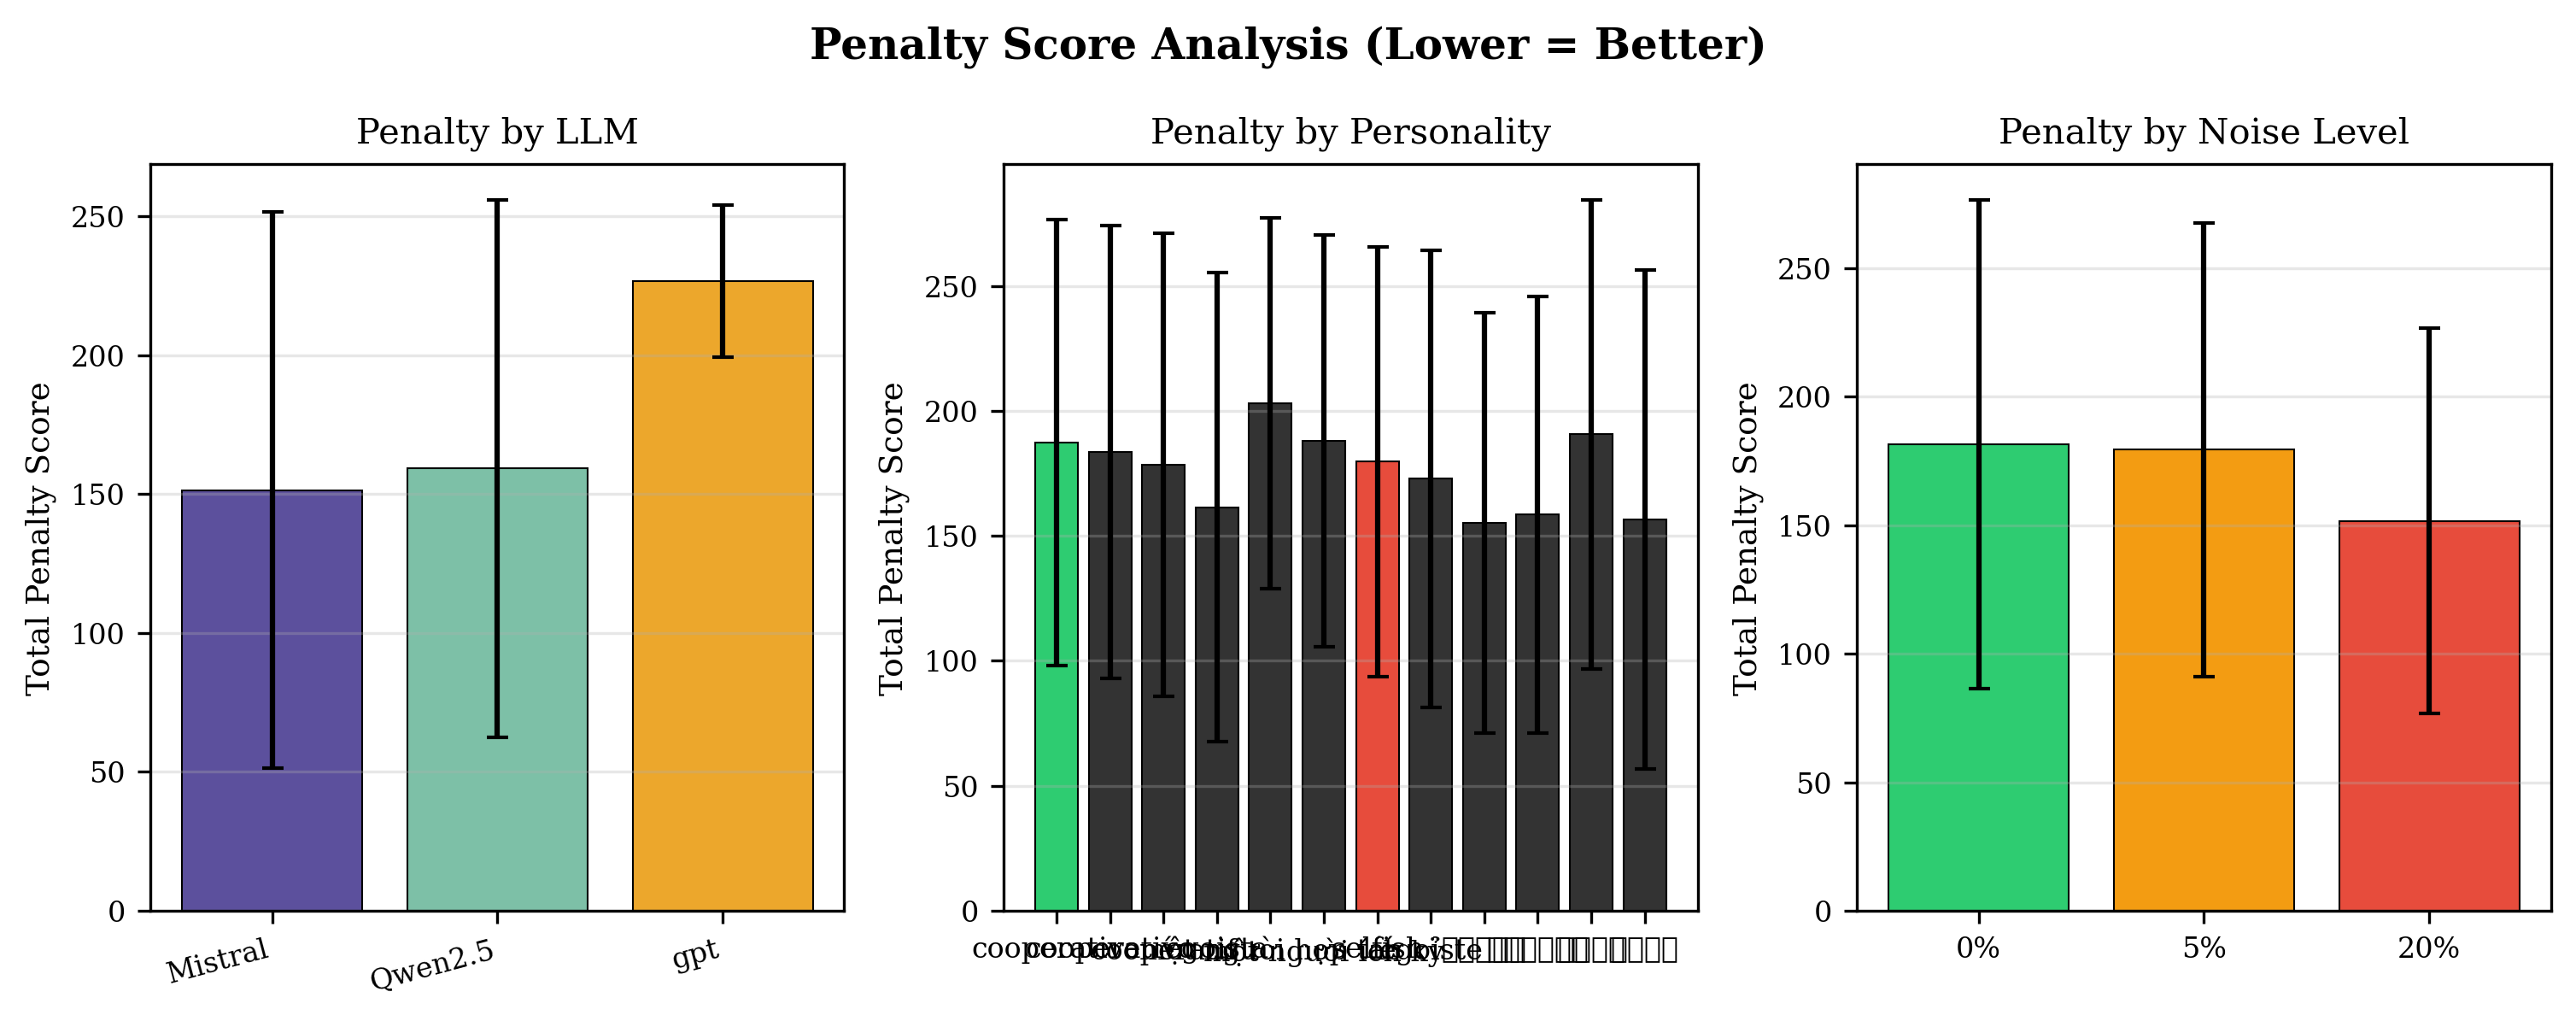

In [40]:
# ============================================================================
# Cell 32: Score Analysis by LLM, Personality, and Noise
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL * 1.5, 4))

# Score by LLM
ax = axes[0]
score_by_llm = agent_df.groupby('llm_name')['total_score'].agg(['mean', 'std'])
colors = [MODEL_COLORS.get(m, '#333') for m in score_by_llm.index]
bars = ax.bar(range(len(score_by_llm)), score_by_llm['mean'], 
              yerr=score_by_llm['std'], color=colors, edgecolor='black', 
              linewidth=0.5, capsize=3)
ax.set_xticks(range(len(score_by_llm)))
ax.set_xticklabels([m.split('-')[0] for m in score_by_llm.index], rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Total Penalty Score')
ax.set_title('Penalty by LLM')
ax.grid(axis='y', alpha=0.3)

# Score by Personality
ax = axes[1]
score_by_pers = agent_df.groupby('personality')['total_score'].agg(['mean', 'std'])
colors = [PERSONALITY_COLORS.get(p, '#333') for p in score_by_pers.index]
bars = ax.bar(range(len(score_by_pers)), score_by_pers['mean'],
              yerr=score_by_pers['std'], color=colors, edgecolor='black',
              linewidth=0.5, capsize=3)
ax.set_xticks(range(len(score_by_pers)))
ax.set_xticklabels(score_by_pers.index)
ax.set_ylabel('Total Penalty Score')
ax.set_title('Penalty by Personality')
ax.grid(axis='y', alpha=0.3)

# Score by Noise
ax = axes[2]
score_by_noise = agent_df.groupby('noise_level')['total_score'].agg(['mean', 'std'])
noise_c = [noise_colors.get(n, '#333') for n in score_by_noise.index]
bars = ax.bar(range(len(score_by_noise)), score_by_noise['mean'],
              yerr=score_by_noise['std'], color=noise_c, edgecolor='black',
              linewidth=0.5, capsize=3)
ax.set_xticks(range(len(score_by_noise)))
ax.set_xticklabels([f'{int(n)}%' for n in score_by_noise.index])
ax.set_ylabel('Total Penalty Score')
ax.set_title('Penalty by Noise Level')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Penalty Score Analysis (Lower = Better)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig13_score_analysis.png', dpi=DPI)
plt.savefig(FIGURES_DIR / 'fig13_score_analysis.pdf')
plt.show()

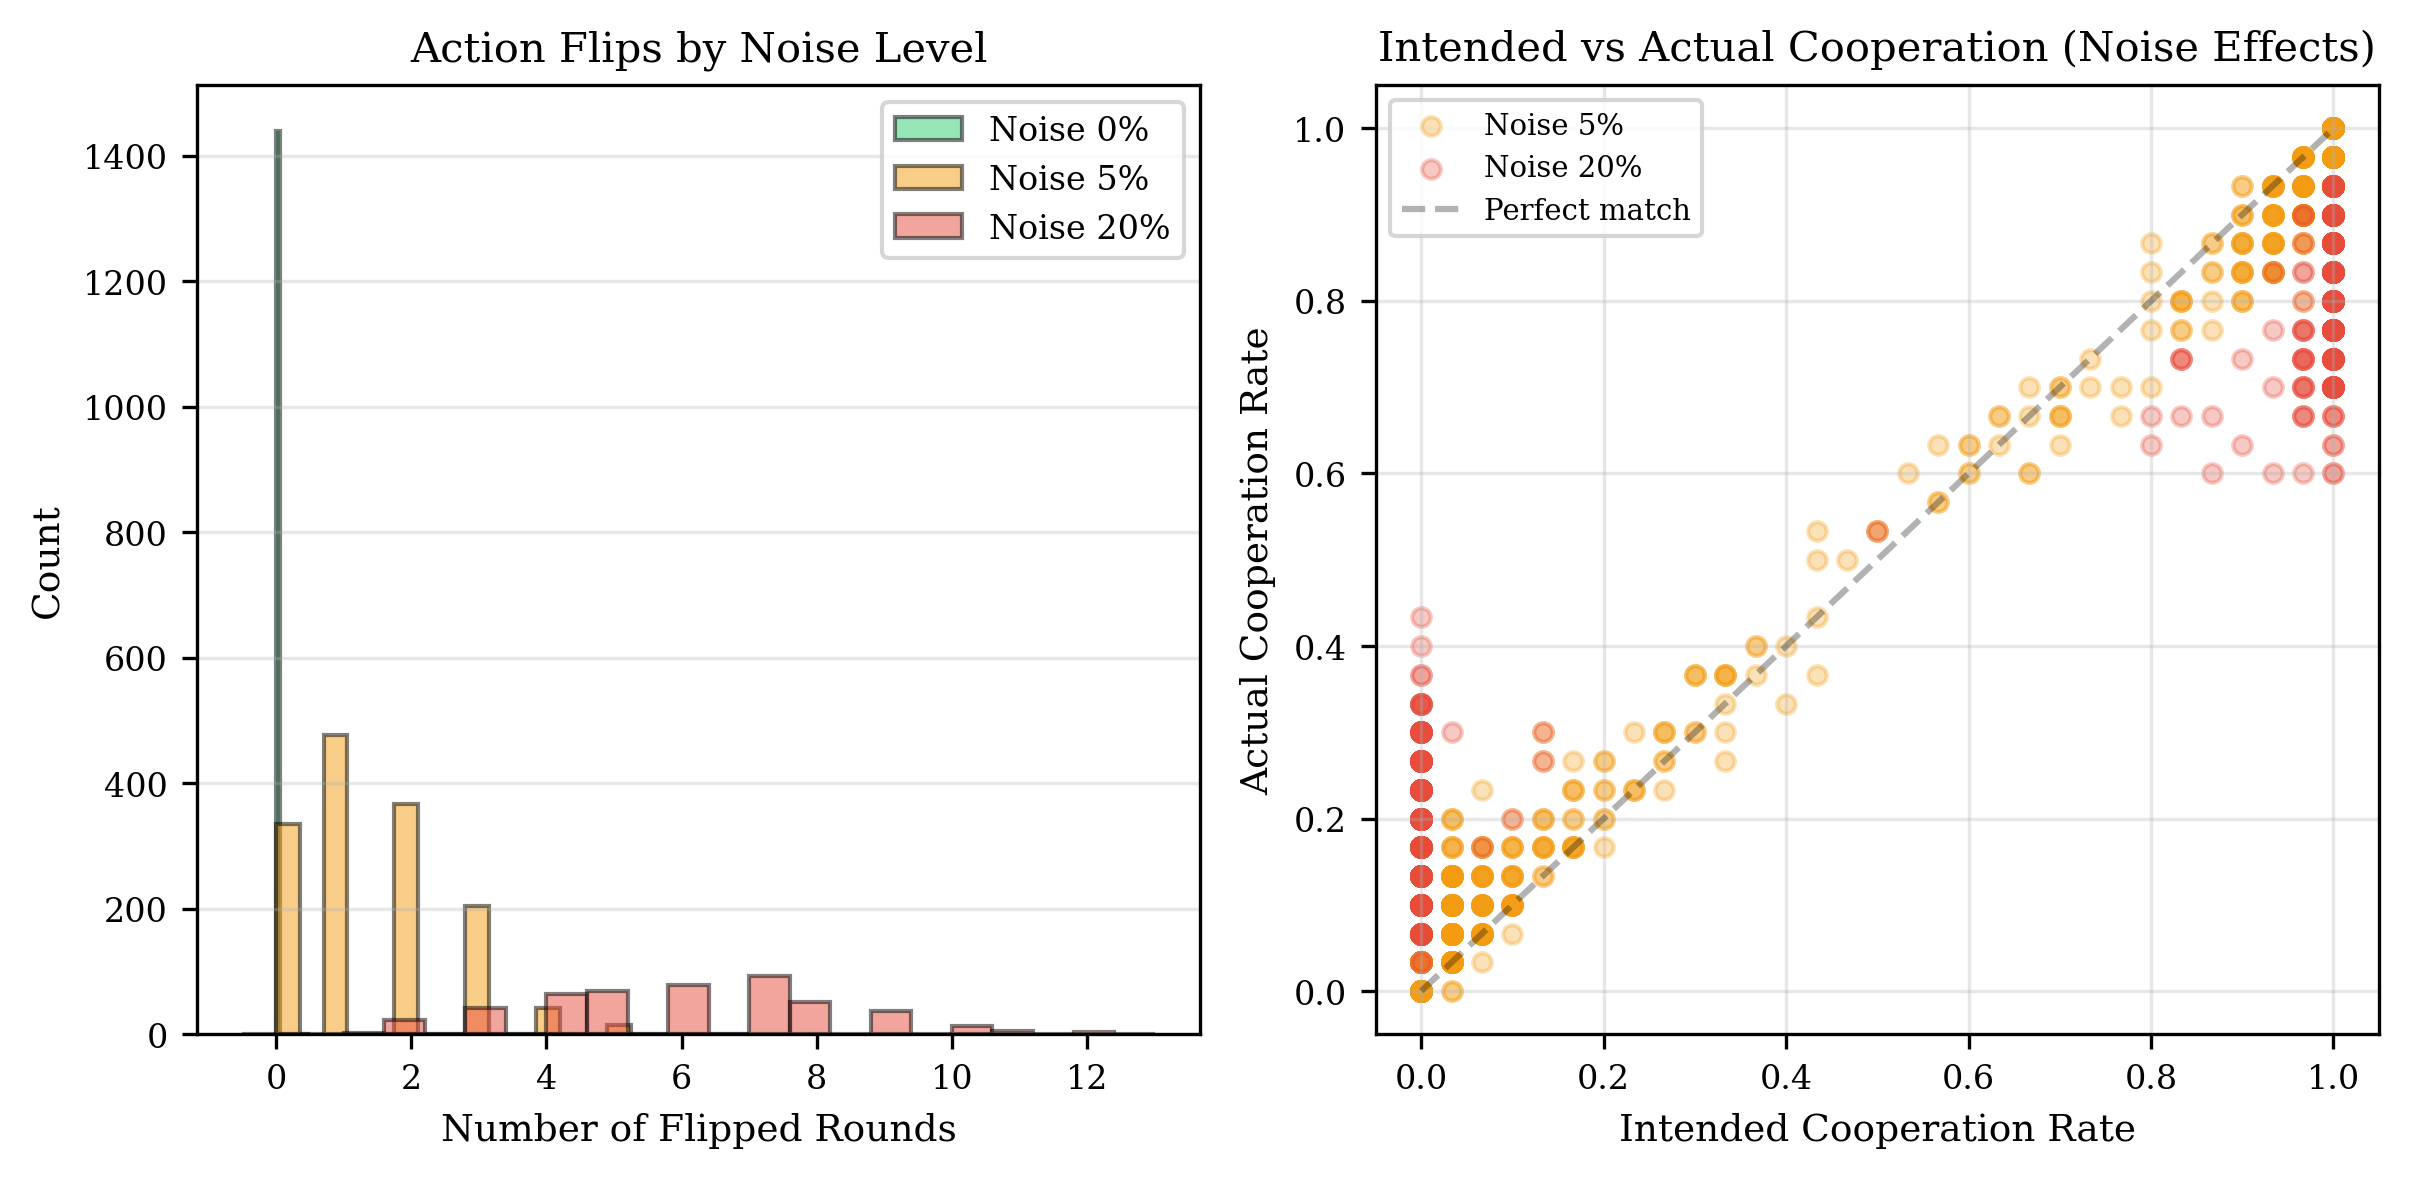

In [43]:
# ============================================================================
# Cell 33: Noise Effect - Intended vs Actual Strategy Flip Analysis
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(DOUBLE_COL * 1.2, 4))

# Flip count distribution by noise level
ax = axes[0]
for noise in sorted(agent_df['noise_level'].unique()):
    subset = agent_df[agent_df['noise_level'] == noise]
    flip_counts = subset['flipped_count']
    color = noise_colors.get(noise, '#333')
    ax.hist(flip_counts, bins=20, alpha=0.5, label=f'Noise {noise}%', color=color, edgecolor='black')
ax.set_xlabel('Number of Flipped Rounds')
ax.set_ylabel('Count')
ax.set_title('Action Flips by Noise Level')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Intended vs actual cooperation rate
ax = axes[1]
for noise in sorted(agent_df['noise_level'].unique()):
    if noise == 0:
        continue
    subset = agent_df[agent_df['noise_level'] == noise].copy()
    
    # Compute intended cooperation rate
    intended_coop = []
    for _, row in subset.iterrows():
        intended = parse_strategy_string(row['intended_strategies'])
        if intended:
            intended_coop.append(sum(1 for s in intended if normalize_action(s) == 'C') / len(intended))
        else:
            intended_coop.append(np.nan)
    subset['intended_coop_rate'] = intended_coop
    
    color = noise_colors.get(noise, '#333')
    ax.scatter(subset['intended_coop_rate'], subset['cooperation_rate'],
              alpha=0.3, color=color, label=f'Noise {noise}%', s=20)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect match')
ax.set_xlabel('Intended Cooperation Rate')
ax.set_ylabel('Actual Cooperation Rate')
ax.set_title('Intended vs Actual Cooperation (Noise Effects)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig14_noise_flip_analysis.png', dpi=DPI)
plt.savefig(FIGURES_DIR / 'fig14_noise_flip_analysis.pdf')
plt.show()

---
## Part X: Save All Results

In [41]:
# ============================================================================
# Cell 34: Save All Results to CSV
# ============================================================================

ANALYSIS_DIR = BASE_DIR / 'analysis_results'
ANALYSIS_DIR.mkdir(exist_ok=True)

# 1. Agent-level predictions
agent_df.to_csv(ANALYSIS_DIR / 'agent_predictions.csv', index=False)
print(f'Saved: agent_predictions.csv ({len(agent_df)} rows)')

# 2. Expanded strategy assignments
df_all.to_csv(ANALYSIS_DIR / 'all_agent_strategies.csv', index=False)
print(f'Saved: all_agent_strategies.csv ({len(df_all)} rows)')

# 3. Behavioral profiles
df_profiles.to_csv(ANALYSIS_DIR / 'behavioral_profiles.csv', index=False)
print(f'Saved: behavioral_profiles.csv ({len(df_profiles)} rows)')

# 4. SFEM results
if len(df_sfem) > 0:
    df_sfem.to_csv(ANALYSIS_DIR / 'sfem_results.csv', index=False)
    print(f'Saved: sfem_results.csv ({len(df_sfem)} rows)')

# 5. Model evaluation
df_eval.to_csv(ANALYSIS_DIR / 'model_evaluation.csv', index=False)
print(f'Saved: model_evaluation.csv ({len(df_eval)} rows)')

# 6. 3-player results
if len(df_agents_3p) > 0:
    df_agents_3p.to_csv(ANALYSIS_DIR / '3player_analysis.csv', index=False)
    print(f'Saved: 3player_analysis.csv ({len(df_agents_3p)} rows)')

print(f'\nAll results saved to: {ANALYSIS_DIR}')
print(f'All figures saved to: {FIGURES_DIR}')
print(f'\nFigures generated:')
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(f'  {f.name}')

Saved: agent_predictions.csv (3360 rows)
Saved: all_agent_strategies.csv (4611 rows)
Saved: behavioral_profiles.csv (3360 rows)
Saved: sfem_results.csv (98 rows)
Saved: model_evaluation.csv (3 rows)
Saved: 3player_analysis.csv (807 rows)

All results saved to: d:\AI_RESEARCH\nicer_fairgame\nicer_fairgame_combined\analysis_results
All figures saved to: d:\AI_RESEARCH\nicer_fairgame\nicer_fairgame_combined\figures

Figures generated:
  cooperation_dynamics_by_model.png
  cooperation_dynamics_personality_noise.png
  fig10_comprehension_analysis.png
  fig11_unfit_rate_vs_threshold.png
  fig12_2p_vs_3p_comparison.png
  fig13_score_analysis.png
  fig1_overall_strategy_distribution.png
  fig2_strategy_by_llm.png
  fig3_strategy_by_personality.png
  fig4_strategy_trends_by_noise.png
  fig5_cooperation_types_combined.png
  fig6_behavioral_radar_charts.png
  fig7_sfem_results.png
  fig8_noise_llm_interaction.png
  fig9_behavioral_heatmap.png
  lstm_model_performance.png


In [42]:
# ============================================================================
# Cell 35: Summary Statistics for Paper
# ============================================================================

print('=' * 70)
print('SUMMARY STATISTICS FOR PAPER')
print('=' * 70)

print(f'\n--- Dataset Overview ---')
print(f'Total 2-player games: {len(df_games)}')
print(f'Total agent observations: {len(agent_df)}')
print(f'LLM models tested: {list(df_games["llm_name"].unique())}')
print(f'Noise levels: {sorted(df_games["noise_level"].unique())}')
print(f'Rounds per game: {df_games["max_rounds"].mode().values[0]}')
if len(df_games_3p) > 0:
    print(f'Total 3-player games: {len(df_games_3p)}')

print(f'\n--- Overall Cooperation ---')
print(f'Mean cooperation rate: {agent_df["cooperation_rate"].mean():.4f} ± {agent_df["cooperation_rate"].std():.4f}')
for llm in agent_df['llm_name'].unique():
    m_data = agent_df[agent_df['llm_name'] == llm]
    print(f'  {llm}: {m_data["cooperation_rate"].mean():.4f} ± {m_data["cooperation_rate"].std():.4f}')

print(f'\n--- Strategy Detection ---')
print(f'LSTM model used: {SELECTED_MODEL} ({list(label_encoder.classes_)})')
print(f'Confidence threshold: {CONFIDENCE_THRESHOLD}')
n_filtered = len(agent_df) - len(df_main)
print(f'Agents above threshold: {len(df_main)} / {len(agent_df)} ({len(df_main)/len(agent_df)*100:.1f}%)')
print(f'Rule-based overrides: {override_count} ({override_count/len(agent_df)*100:.1f}%)')

print(f'\n--- Strategy Proportions ---')
for strat, count in df_all['predicted_strategy'].value_counts().items():
    pct = count / len(df_all) * 100
    print(f'  {strat}: {count} ({pct:.1f}%)')

print(f'\n--- Behavioral Profile (Overall) ---')
for dim in dims:
    mean = df_profiles[dim].mean()
    std = df_profiles[dim].std()
    print(f'  {dim:15s}: {mean:.4f} ± {std:.4f}')

if len(df_sfem) > 0:
    print(f'\n--- Top SFEM Strategies ---')
    top_sfem = df_sfem.groupby('strategy')['sfem_score'].mean().sort_values(ascending=False)
    for strat, score in top_sfem.items():
        print(f'  {strat}: {score:.4f}')

print(f'\n--- Comprehension Questions ---')
for col in ['time_checker_accuracy', 'rule_checker_accuracy', 'aggregation_checker_accuracy']:
    if col in agent_df.columns:
        mean = agent_df[col].mean()
        print(f'  {col.replace("_", " ").title()}: {mean:.4f}')

SUMMARY STATISTICS FOR PAPER

--- Dataset Overview ---
Total 2-player games: 1680
Total agent observations: 3360
LLM models tested: ['Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct', 'gpt-oss-20b']
Noise levels: [np.int64(0), np.int64(5), np.int64(20)]
Rounds per game: 30
Total 3-player games: 269

--- Overall Cooperation ---
Mean cooperation rate: 0.3540 ± 0.4111
  Mistral-7B-Instruct-v0.3: 0.4920 ± 0.4445
  Qwen2.5-32B-Instruct: 0.4489 ± 0.4175
  gpt-oss-20b: 0.0735 ± 0.1464

--- Strategy Detection ---
LSTM model used: 4strat ([np.str_('AllC'), np.str_('AllD'), np.str_('TFT'), np.str_('WSLS')])
Confidence threshold: 0.9
Agents above threshold: 3128 / 3360 (93.1%)
Rule-based overrides: 2156 (64.2%)

--- Strategy Proportions ---
  TFT: 1825 (39.6%)
  AllD: 1366 (29.6%)
  AllC: 778 (16.9%)
  WSLS: 642 (13.9%)

--- Behavioral Profile (Overall) ---
  nice           : 0.1884 ± 0.3911
  forgiving      : 0.1972 ± 0.3446
  retaliatory    : 0.7454 ± 0.4137
  troublemaking  : 0.7828 ± 0.3817
